In [45]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from micom.workflows import load_results
from micom.measures import production_rates, consumption_rates
from skbio.stats.composition import clr
from sklearn.metrics import pairwise_distances
from scipy.cluster.hierarchy import linkage, cophenet
from matplotlib.lines import Line2D
from skbio.diversity import beta_diversity
from scipy.spatial.distance import squareform
from statannot import add_stat_annotation

%matplotlib inline

### Preprocess the data by binarzing gene count matrix against presence/absence

In [2]:
gene_count = pd.read_csv('../raw/agora_metabolism-module_stepwise_completeness-MATRIX.txt', sep='\t')
taxonomy = pd.read_csv('../processed/reference_taxonomy.csv')
taxonomy['NCBI Taxonomy ID'] = taxonomy['NCBI Taxonomy ID'].astype('str').str.replace('.0', '', regex=False)
abundance = pd.read_csv('../processed/abundance_normalized_table.csv', index_col=0)
DonorRecipientMapping = pd.read_csv('../raw/DonorRecipientMapping.csv')
DonorRecipientMapping['donor'] = DonorRecipientMapping['donor'].str.split('_').str[0]
DonorRecipientMapping['recipient'] = DonorRecipientMapping['recipient'].str.split('_').str[0]
donors = DonorRecipientMapping['donor'].unique().tolist()
recipients_t6 = DonorRecipientMapping['recipient'].str.replace('-0', '-6').tolist()
recipients_t0 = [recipient.replace('-6', '-0') for recipient in recipients_t6]
all_samples = set(donors+recipients_t0+recipients_t6)
growth_rates = load_results('../models/res_western.zip').growth_rates
exchanges = load_results('../models/res_western.zip').exchanges
model_samples = set(growth_rates['sample_id'].unique().tolist())
samples = model_samples.intersection(all_samples)
gene_count = (
    gene_count
    .melt(id_vars='module', var_name='id', value_name='stepwise_completeness')
    .merge(
        taxonomy[['NCBI Taxonomy ID', 'id']],
        on='id',
        how='left'
    )
    .drop(columns=['id'])
    .pivot_table(
        index='NCBI Taxonomy ID',
        columns='module',
        values='stepwise_completeness',
        fill_value=0
    )
) # standard scaler is not needed since the data is already in 0 - 1 scale
gene_count.index = gene_count.index.astype(int)
gene_count = gene_count.sort_index()
print(gene_count.shape)
# convert abundance to relative abundance and apply the 0.0001 threshold
threshold = 0.0001

abundance_binarized = (abundance / abundance.sum(axis=0) > threshold).astype(int)
abundance_binarized = abundance_binarized.loc[:, abundance_binarized.columns.isin(samples)]
print(abundance_binarized.shape)

abundance_weighted_completness = pd.DataFrame(abundance_binarized.values.T @ gene_count.values, index=abundance_binarized.columns, columns=gene_count.columns)
abundance_weighted_completness

/opt/anaconda3/envs/qiime2/lib/python3.9/site-packages/micom/workflows/results.py:55: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  tab = pd.read_csv(zippy.open(f"{attr}.csv", "r"))
/opt/anaconda3/envs/qiime2/lib/python3.9/site-packages/micom/workflows/results.py:55: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  tab = pd.read_csv(zippy.open(f"{attr}.csv", "r"))


(806, 479)
(806, 59)


module,M00001,M00002,M00003,M00004,M00005,M00006,M00007,M00008,M00009,M00010,...,M00964,M00965,M00966,M00967,M00968,M00969,M00970,M00971,M00972,M00973
33-0,173.333333,182.2,171.428571,146.000000,186.0,99.0,170.25,90.50,109.875,112.000000,...,0.0,0.0,0.00,7.666667,0.666667,0.0,67.0,0.0,65.333333,5.333333
77-6,209.222222,219.0,205.142857,176.333333,223.0,125.0,203.00,109.00,129.375,131.666667,...,0.0,0.0,0.00,7.000000,0.666667,0.0,78.0,0.0,79.333333,6.333333
22-6,199.000000,207.4,194.571429,167.666667,212.0,115.5,194.50,104.25,125.875,131.666667,...,0.0,0.0,0.00,8.666667,1.666667,0.0,74.0,0.0,76.333333,6.333333
90-6,201.888889,211.6,199.285714,170.000000,216.0,118.0,197.00,106.50,126.250,125.333333,...,0.0,0.0,0.00,7.333333,0.666667,0.0,79.0,0.0,77.666667,6.666667
16-0,168.888889,175.4,164.571429,143.333333,178.0,103.5,163.75,91.75,110.875,114.000000,...,0.0,0.0,0.00,6.000000,1.333333,0.0,66.0,0.0,69.333333,5.666667
D-6Fresk,162.000000,169.4,159.714286,136.333333,173.0,92.0,159.25,84.25,99.375,102.333333,...,0.0,0.0,0.00,6.000000,0.666667,0.0,58.0,0.0,61.000000,4.666667
78-6,167.777778,176.0,166.000000,140.333333,180.0,93.0,164.75,83.75,106.250,105.666667,...,0.0,0.0,0.00,5.666667,0.666667,0.0,64.0,0.0,64.000000,5.333333
12-6,205.666667,214.2,200.285714,172.666667,218.0,120.0,199.75,109.25,129.125,134.333333,...,0.0,0.0,0.00,6.333333,1.000000,0.0,78.0,0.0,80.333333,6.000000
11-6,177.111111,186.4,175.142857,148.166667,190.0,99.5,173.50,92.00,108.375,109.333333,...,0.0,0.0,0.00,7.666667,0.666667,0.0,67.0,0.0,65.666667,5.333333
75-0,185.111111,193.2,181.571429,155.166667,197.0,107.0,180.00,97.00,116.125,118.333333,...,0.0,0.0,0.00,8.000000,0.666667,0.0,70.0,0.0,70.333333,5.333333


In [3]:
abundance_weighted_completness_clr = clr(abundance_weighted_completness.values + 1e-6)
ak_distance = pd.DataFrame(pairwise_distances(abundance_weighted_completness_clr, metric='euclidean'), index=abundance_weighted_completness.index, columns=abundance_weighted_completness.index)
ak_distance

,33-0,77-6,22-6,90-6,16-0,D-6Fresk,78-6,12-6,11-6,75-0,...,90-0,D-5Fryst,18-6,88-6,D-14,78-0,16-6,19-0,75-6,36-0
33-0,0.000000,33.696874,25.349198,29.706148,28.915752,32.635918,31.785143,39.360970,26.372957,38.715496,...,27.077715,38.972264,39.424801,26.651310,25.621367,31.733107,28.319367,36.571104,33.688919,28.489927
77-6,33.696874,0.000000,22.358680,30.314577,18.830465,34.377108,36.901849,37.206744,32.939405,39.182105,...,39.883501,43.584166,33.422299,27.327500,31.922933,32.492007,30.181431,33.023578,34.318064,24.030624
22-6,25.349198,22.358680,0.000000,29.170002,12.598320,33.256379,35.959959,30.591110,31.795394,38.611945,...,33.240309,42.914762,30.285015,25.994857,30.673664,31.526584,28.704253,32.312850,33.470211,22.662269
90-6,29.706148,30.314577,29.170002,0.000000,31.697890,34.595772,33.610509,41.925082,28.726232,30.691774,...,30.564337,40.753368,41.736348,23.259026,27.786863,28.265381,30.564917,27.906477,24.108266,24.937662
16-0,28.915752,18.830465,12.598320,31.697890,0.000000,35.582607,38.549897,32.163669,34.371297,40.262968,...,35.442280,45.271241,32.252805,29.405742,33.566324,33.836748,31.534898,33.877893,35.479508,25.201452
D-6Fresk,32.635918,34.377108,33.256379,34.595772,35.582607,0.000000,37.133777,40.623332,27.461066,42.737925,...,38.903604,27.727244,44.269640,32.093850,20.361319,36.924349,16.668768,37.115270,38.478384,29.246670
78-6,31.785143,36.901849,35.959959,33.610509,38.549897,37.133777,0.000000,46.757038,31.491719,28.591708,...,41.717273,24.194069,46.779908,24.695994,30.745426,18.574478,32.776516,26.035689,28.974592,32.697454
12-6,39.360970,37.206744,30.591110,41.925082,32.163669,40.623332,46.757038,0.000000,39.543222,41.784710,...,44.834856,48.903109,17.397903,40.057742,38.747351,43.094237,41.062726,43.574668,44.798784,37.452785
11-6,26.372957,32.939405,31.795394,28.726232,34.371297,27.461066,31.491719,39.543222,0.000000,38.193240,...,37.742960,34.975437,43.061179,25.818397,17.834112,31.066364,28.088793,36.130090,33.011413,27.443298
75-0,38.715496,39.182105,38.611945,30.691774,40.262968,42.737925,28.591708,41.784710,38.193240,0.000000,...,43.325448,36.882264,41.694346,33.966648,37.268624,22.217987,39.437891,21.513883,25.355751,35.393387


In [4]:
b = beta_diversity("braycurtis", abundance.values.T, ids=abundance.columns)
dist_condensed = squareform(b.data, checks=False)
Z = linkage(dist_condensed, method="average")
coph_corr, coph_condensed = cophenet(Z, dist_condensed)
print("Cophenetic correlation coefficient:", coph_corr)
coph_square = squareform(coph_condensed)
coph_matrix = pd.DataFrame(
    coph_square,
    index=abundance.columns,
    columns=abundance.columns
)
coph_matrix

Cophenetic correlation coefficient: 0.7519490742726419


,33-0,D-15U,77-6,22-6,90-6,16-0,D-6Fryst,D-6Fresk,78-6,12-6,...,D-5Fryst,18-6,88-6,D-14,D-14U,78-0,16-6,19-0,75-6,36-0
33-0,0.000000,0.692245,0.756953,0.586503,0.396431,0.586503,0.692245,0.692245,0.726867,0.756953,...,0.692245,0.874711,0.692245,0.692245,0.692245,0.726867,0.692245,0.659198,0.815301,0.726867
D-15U,0.692245,0.000000,0.756953,0.692245,0.692245,0.692245,0.587357,0.666858,0.726867,0.756953,...,0.587357,0.874711,0.587357,0.587357,0.587357,0.726867,0.556409,0.692245,0.815301,0.726867
77-6,0.756953,0.756953,0.000000,0.756953,0.756953,0.756953,0.756953,0.756953,0.756953,0.704673,...,0.756953,0.874711,0.756953,0.756953,0.756953,0.756953,0.756953,0.756953,0.815301,0.756953
22-6,0.586503,0.692245,0.756953,0.000000,0.586503,0.534822,0.692245,0.692245,0.726867,0.756953,...,0.692245,0.874711,0.692245,0.692245,0.692245,0.726867,0.692245,0.659198,0.815301,0.726867
90-6,0.396431,0.692245,0.756953,0.586503,0.000000,0.586503,0.692245,0.692245,0.726867,0.756953,...,0.692245,0.874711,0.692245,0.692245,0.692245,0.726867,0.692245,0.659198,0.815301,0.726867
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78-0,0.726867,0.726867,0.756953,0.726867,0.726867,0.726867,0.726867,0.726867,0.379675,0.756953,...,0.726867,0.874711,0.726867,0.726867,0.726867,0.000000,0.726867,0.726867,0.815301,0.635604
16-6,0.692245,0.556409,0.756953,0.692245,0.692245,0.692245,0.587357,0.666858,0.726867,0.756953,...,0.587357,0.874711,0.587357,0.587357,0.587357,0.726867,0.000000,0.692245,0.815301,0.726867
19-0,0.659198,0.692245,0.756953,0.659198,0.659198,0.659198,0.692245,0.692245,0.726867,0.756953,...,0.692245,0.874711,0.692245,0.692245,0.692245,0.726867,0.692245,0.000000,0.815301,0.726867
75-6,0.815301,0.815301,0.815301,0.815301,0.815301,0.815301,0.815301,0.815301,0.815301,0.815301,...,0.815301,0.874711,0.815301,0.815301,0.815301,0.815301,0.815301,0.815301,0.000000,0.815301


In [5]:
def get_similarity_from_features(X, metric="euclidean"):
    """
    Python version of R get.euc(mat, alt = 'euclidean').
    
    Parameters
    ----------
    X : pd.DataFrame or np.ndarray
        Feature matrix, shape (n_samples, n_features).
    metric : str
        Distance metric passed to sklearn.metrics.pairwise_distances.
        Default 'euclidean'. You could also use 'cosine', etc.
    
    Returns
    -------
    C : np.ndarray
        Similarity matrix, shape (n_samples, n_samples),
        where C[i, j] = 1 / distance(i, j), with diagonal = 0.
    """
    if isinstance(X, pd.DataFrame):
        X_vals = X.values
    else:
        X_vals = np.asarray(X)
    
    # 1) Compute pairwise distances between rows of X
    if metric == 'euclidean':
        D = pairwise_distances(X_vals, metric=metric)
    elif metric == 'mahalanobis':
        from sklearn.covariance import LedoitWolf
        cov = LedoitWolf().fit(X_vals)
        S_inv = cov.precision_
        D = pairwise_distances(X_vals, metric=metric, VI=S_inv)
    
    # 2) Convert distance to similarity: C_ij = 1 / D_ij
    #    Guard against division by zero if identical rows exist.
    with np.errstate(divide="ignore"):
        C = 1.0 / D
    
    # 3) Explicitly zero out diagonal (self-similarities).
    np.fill_diagonal(C, 0.0)
    
    # 4) Replace any inf that might occur (from D_ij = 0) with 0
    C[~np.isfinite(C)] = 0.0
    
    return C

In [6]:
def threshold_similarity(C, top_k=25):
    """
    Python version of R threshold(mat, top_k).
    
    Parameters
    ----------
    C : np.ndarray
        Similarity matrix, shape (n_samples, n_samples).
    top_k : int
        Number of largest similarities to keep per row.
    
    Returns
    -------
    C_thr : np.ndarray
        Thresholded and symmetrized similarity matrix.
    """
    C = np.asarray(C)
    n = C.shape[0]
    C_thr = C.copy()
    
    # 1) For each row, keep only the top_k largest values, set others to 0
    for i in range(n):
        row = C_thr[i, :]
        # argsort descending; keep indices of top_k values
        # tie-breaking is natural from argsort, similar to ties.method = 'random' not needed here
        top_idx = np.argpartition(-row, top_k - 1)[:top_k]
        
        mask = np.ones(n, dtype=bool)
        mask[top_idx] = False  # False where we keep, True where we zero
        
        C_thr[i, mask] = 0.0
    
    # 2) Symmetrize: if C_thr[i,j] == 0 but C_thr[j,i] != 0, copy value.
    for i in range(n):
        for j in range(n):
            if C_thr[i, j] == 0.0 and C_thr[j, i] != 0.0:
                C_thr[i, j] = C_thr[j, i]
    
    return C_thr

In [7]:
def get_laplacian(C_thr):
    """
    Python version of R get.laplac(mat).
    
    Parameters
    ----------
    C_thr : np.ndarray
        Thresholded similarity matrix, shape (n_samples, n_samples).
    
    Returns
    -------
    L_norm : np.ndarray
        Row-normalized Laplacian matrix, shape (n_samples, n_samples).
    """
    C_thr = np.asarray(C_thr)
    n = C_thr.shape[0]
    
    # L starts as negative similarities
    L = -C_thr.copy()
    
    # Row sums of similarity matrix (denominator for normalization)
    S = C_thr.sum(axis=1)  # shape (n,)
    
    # Avoid division by zero: if a row sum is 0 (completely isolated node), keep row of zeros for now
    S_safe = S.copy()
    S_safe[S_safe == 0] = 1.0
    
    # Normalize rows: L_norm[i, j] = -C_thr[i, j] / S[i] for i != j
    L_norm = L / S_safe[:, None]
    
    # Set diagonal to 1 as in the R function
    np.fill_diagonal(L_norm, 1.0)
    
    return L_norm

In [8]:
def diffusion_map_from_laplacian(L_norm, n_components=5):
    """
    Compute diffusion map coordinates from a normalized Laplacian
    (Barter & Gross style).
    
    Parameters
    ----------
    L_norm : np.ndarray
        Normalized Laplacian, shape (n_samples, n_samples).
    n_components : int
        Number of non-trivial eigenvectors (variables) to return.
    
    Returns
    -------
    evals : np.ndarray
        Eigenvalues sorted ascending, shape (n_samples,).
    evecs : np.ndarray
        Corresponding eigenvectors as columns, shape (n_samples, n_samples).
    diff_coords : np.ndarray
        Diffusion coordinates, shape (n_samples, n_components).
        These are the eigenvectors associated with the smallest non-zero eigenvalues.
    """
    # Ensure array
    L_norm = np.asarray(L_norm)
    
    # Eigendecomposition (L_norm should be symmetric)
    evals, evecs = np.linalg.eigh(L_norm)
    
    # Sort eigenvalues/eigenvectors ascending by eigenvalue
    idx = np.argsort(evals)
    evals = evals[idx]
    evecs = evecs[:, idx]
    
    # The smallest eigenvalue is the trivial one; ignore it
    # Variables 1..n_components correspond to the next eigenvectors
    # (smallest non-zero eigenvalues).
    diff_coords = evecs[:, 1:n_components + 1]
    
    return evals, evecs, diff_coords

In [9]:
ex = (
    exchanges
    .query('direction == "export" and sample_id in @samples and taxon != "medium"')
    .assign(flux=lambda x: x['flux'] * x['abundance'])
    .pivot_table(
        index='sample_id',
        columns='metabolite',
        values='flux',
        fill_value=0
    )
    .copy()
)
ex_transformed = StandardScaler().fit_transform(ex.values)
ex_transformed = pd.DataFrame(ex_transformed, index=ex.index, columns=ex.columns)

C = get_similarity_from_features(ex_transformed, metric="euclidean")
C_thr = threshold_similarity(C, top_k=25)
L_norm = get_laplacian(C_thr)
evals, evecs, diff_coords = diffusion_map_from_laplacian(L_norm, n_components=2)
diffusion_df = pd.DataFrame(
    diff_coords,
    index=ex_transformed.index,
    columns=['Diffusion1', 'Diffusion2']
)
diffusion_df

,Diffusion1,Diffusion2
sample_id,,
11-0,0.215429,-0.081302
11-6,0.171971,-0.133655
12-0,0.049483,0.150195
12-6,-0.016373,0.160815
16-0,0.240384,-0.082486
16-6,0.043294,0.003495
18-0,-0.002681,0.038508
18-6,-0.004556,0.042521
19-0,0.034036,0.235317


In [10]:
# # 1) Start from your existing distance matrix (59 × 59 DataFrame)
# D = ak_distance.values  # shape: (59, 59)

# # 2) Build similarity matrix C_ij = 1 / D_ij, with diagonal = 0
# with np.errstate(divide="ignore"):
#     C = 1.0 / D
# np.fill_diagonal(C, 0.0)
# C[~np.isfinite(C)] = 0.0  # replace inf/nan (from D_ij = 0) with 0

# # 3) Threshold similarity matrix (e.g., top_k=25 as in the paper)
# C_thr = threshold_similarity(C, top_k=25)

# # 4) Compute normalized Laplacian
# L_norm = get_laplacian(C_thr)

# # 5) Eigendecomposition → diffusion coordinates
# evals, evecs, diff_coords = diffusion_map_from_laplacian(L_norm, n_components=2)

# # 6) Wrap diffusion coordinates into a DataFrame with sample IDs
# diffusion_df = pd.DataFrame(
#     diff_coords,
#     index=ak_distance.index,
#     columns=[f"DM{i}" for i in range(1, diff_coords.shape[1] + 1)]
# )

# print(diffusion_df.head())

In [11]:
group_labels = pd.DataFrame(samples, columns=['sample'])
group_labels['type'] = group_labels['sample'].apply(lambda x: 'donor' if x.startswith('D') else 'recipient T0' if x.endswith('-0') else 'recipient T6')
T6_mapping = {row['recipient'].replace('-0', '-6'): row['clinical_response'] for _, row in DonorRecipientMapping.iterrows()}
DonorRecipientMapping_t6 = pd.DataFrame({
    'recipient': list(T6_mapping.keys()),
    'clinical_response': list(T6_mapping.values())
})
group_labels = group_labels.merge(DonorRecipientMapping_t6, left_on='sample', right_on='recipient', how='left')
group_labels['clinical_response'] = group_labels['clinical_response'].fillna(group_labels['type'])
group_labels.set_index('sample', inplace=True)
group_labels = group_labels['clinical_response']
group_labels

sample
D-4                  donor
D-14                 donor
24-6             responder
70-0          recipient T0
88-6             responder
24-0          recipient T0
D-10                 donor
78-0          recipient T0
90-0          recipient T0
59-6             responder
36-0          recipient T0
12-6         non-responder
30-6             responder
D-7Fryst             donor
19-6             responder
89-6             responder
D-15Fryst            donor
71-0          recipient T0
19-0          recipient T0
32-0          recipient T0
11-6             responder
56-6         non-responder
12-0          recipient T0
18-0          recipient T0
77-6             responder
D-3                  donor
D-2                  donor
25-0          recipient T0
31-0          recipient T0
D-6Fresk             donor
22-6         non-responder
16-6             responder
D-13U                donor
77-0          recipient T0
78-6             responder
88-0          recipient T0
D-9Fryst             

In [12]:
def build_pairwise_table(dist_matrix, coph_matrix, group_labels, diff_dist_matrix=None):
    rows = []
    samples = dist_matrix.index.tolist()

    for i in range(len(samples)):
        for j in range(i + 1, len(samples)):
            s_i = samples[i]
            s_j = samples[j]

            # original distance (Aitchison)
            orig_d = dist_matrix.loc[s_i, s_j]

            # cophenetic distance
            coph_d = coph_matrix.loc[s_i, s_j]

            # diffusion distance (optional)
            if diff_dist_matrix is not None:
                diff_d = diff_dist_matrix.loc[s_i, s_j]
            else:
                diff_d = None

            g_i = group_labels.loc[s_i]
            g_j = group_labels.loc[s_j]
            pair_type = "within_" + g_i if g_i == g_j else "between_groups"

            rows.append({
                "sample_i": s_i,
                "sample_j": s_j,
                "group_i": g_i,
                "group_j": g_j,
                "aitchison_distance": orig_d,
                "cophenetic_distance": coph_d,
                "diffusion_distance": diff_d,
                "pair_type": pair_type
            })

    return pd.DataFrame(rows)

In [13]:
diff_dist_matrix = pd.DataFrame(
    pairwise_distances(diffusion_df.values, metric="euclidean"),
    index=diffusion_df.index,
    columns=diffusion_df.index
)
diff_dist_matrix

sample_id,11-0,11-6,12-0,12-6,16-0,16-6,18-0,18-6,19-0,19-6,...,D-13U,D-14,D-15Fryst,D-2,D-3,D-4,D-5Fryst,D-6Fresk,D-7Fryst,D-9Fryst
sample_id,,,,,,,,,,,,,,,,,,,,,
11-0,0.000000,0.068039,0.284831,0.335191,0.024984,0.191887,0.248850,0.252439,0.364899,0.343000,...,0.149657,0.400315,0.109536,0.330675,0.323055,0.337361,0.398460,0.318126,0.381355,0.449003
11-6,0.068039,0.000000,0.309150,0.349551,0.085432,0.188063,0.245241,0.249399,0.393911,0.304507,...,0.085426,0.353777,0.045726,0.299360,0.290326,0.304079,0.351880,0.279022,0.326021,0.397615
12-0,0.284831,0.309150,0.000000,0.066707,0.300971,0.146830,0.123268,0.120473,0.086513,0.289487,...,0.380650,0.364050,0.308531,0.251154,0.253813,0.263044,0.363008,0.279679,0.400089,0.425868
12-6,0.335191,0.349551,0.066707,0.000000,0.353723,0.168256,0.123071,0.118883,0.089953,0.264194,...,0.412984,0.335398,0.341162,0.224097,0.229419,0.235612,0.334647,0.260024,0.382036,0.396021
16-0,0.024984,0.085432,0.300971,0.353723,0.000000,0.215029,0.271515,0.274996,0.378918,0.367965,...,0.160927,0.424952,0.129614,0.355597,0.348011,0.362322,0.423093,0.343071,0.404847,0.473180
16-6,0.191887,0.188063,0.146830,0.168256,0.215029,0.000000,0.057790,0.061747,0.232007,0.189661,...,0.245170,0.262185,0.173869,0.162474,0.158823,0.172497,0.260666,0.170429,0.277564,0.321857
18-0,0.248850,0.245241,0.123268,0.123071,0.271515,0.057790,0.000000,0.004429,0.200204,0.171367,...,0.297988,0.246573,0.228082,0.136121,0.136354,0.147698,0.245342,0.158503,0.277366,0.308299
18-6,0.252439,0.249399,0.120473,0.118883,0.274996,0.061747,0.004429,0.000000,0.196620,0.172799,...,0.302393,0.248005,0.232444,0.137030,0.137612,0.148684,0.246798,0.160482,0.279831,0.309788
19-0,0.364899,0.393911,0.086513,0.089953,0.378918,0.232007,0.200204,0.196620,0.000000,0.353285,...,0.466867,0.425129,0.394829,0.313330,0.318172,0.324955,0.424348,0.347784,0.469826,0.485900


In [ ]:
def subset_samples_to_plot(groups):
    mask_samples = group_labels.isin(groups)
    subset_samples = group_labels.index[mask_samples]

    ak_sub = ak_distance.loc[subset_samples, subset_samples]
    coph_sub = coph_matrix.loc[subset_samples, subset_samples]
    diff_sub = diff_dist_matrix.loc[subset_samples, subset_samples]

    group_labels_sub = group_labels.loc[subset_samples]
    pairs_sub = build_pairwise_table(
    dist_matrix=ak_sub,
    coph_matrix=coph_sub,
    group_labels=group_labels_sub,
    diff_dist_matrix=diff_sub)

    plt.figure(figsize=(10, 8), dpi=150)
    for group in groups:
        sns.kdeplot(
            data=pairs_sub[pairs_sub['pair_type'] == 'within_' + group],
            x='diffusion_distance',
            y='cophenetic_distance',
            levels=10,
            linewidths=1.5,
        )
    legends = [
        Line2D([0], [0], color=sns.color_palette()[i], lw=2, label=group)
        for i, group in enumerate(groups)
    ]
    plt.legend(
        handles=legends,
        loc="lower right",
        frameon=True,
        fontsize=12)

    # Overlay raw points
    # sns.scatterplot(
    #     data=pairs_sub,
    #     x="diffusion_distance",
    #     y="cophenetic_distance",
    #     color="black",
    #     s=15,
    #     alpha=0.5
    # )

    # # Label points (optional)
    # for _, r in pairs_sub.iterrows():
    #     plt.text(
    #         r['diffusion_distance'],
    #         r['cophenetic_distance'],
    #         f"{r['sample_i']} vs {r['sample_j']}",
    #         fontsize=7,
    #         alpha=0.7
    #     )
    plt.title(f'Cophenetic Distance vs. Diffusion Distance')
    plt.ylim([0,1])
    plt.xlabel('Diffusion Distance')
    plt.ylabel('Cophenetic Distance')
    plt.tight_layout()
    plt.show()  
    return pairs_sub


/opt/anaconda3/envs/qiime2/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/qiime2/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/qiime2/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/qiime2/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future ver

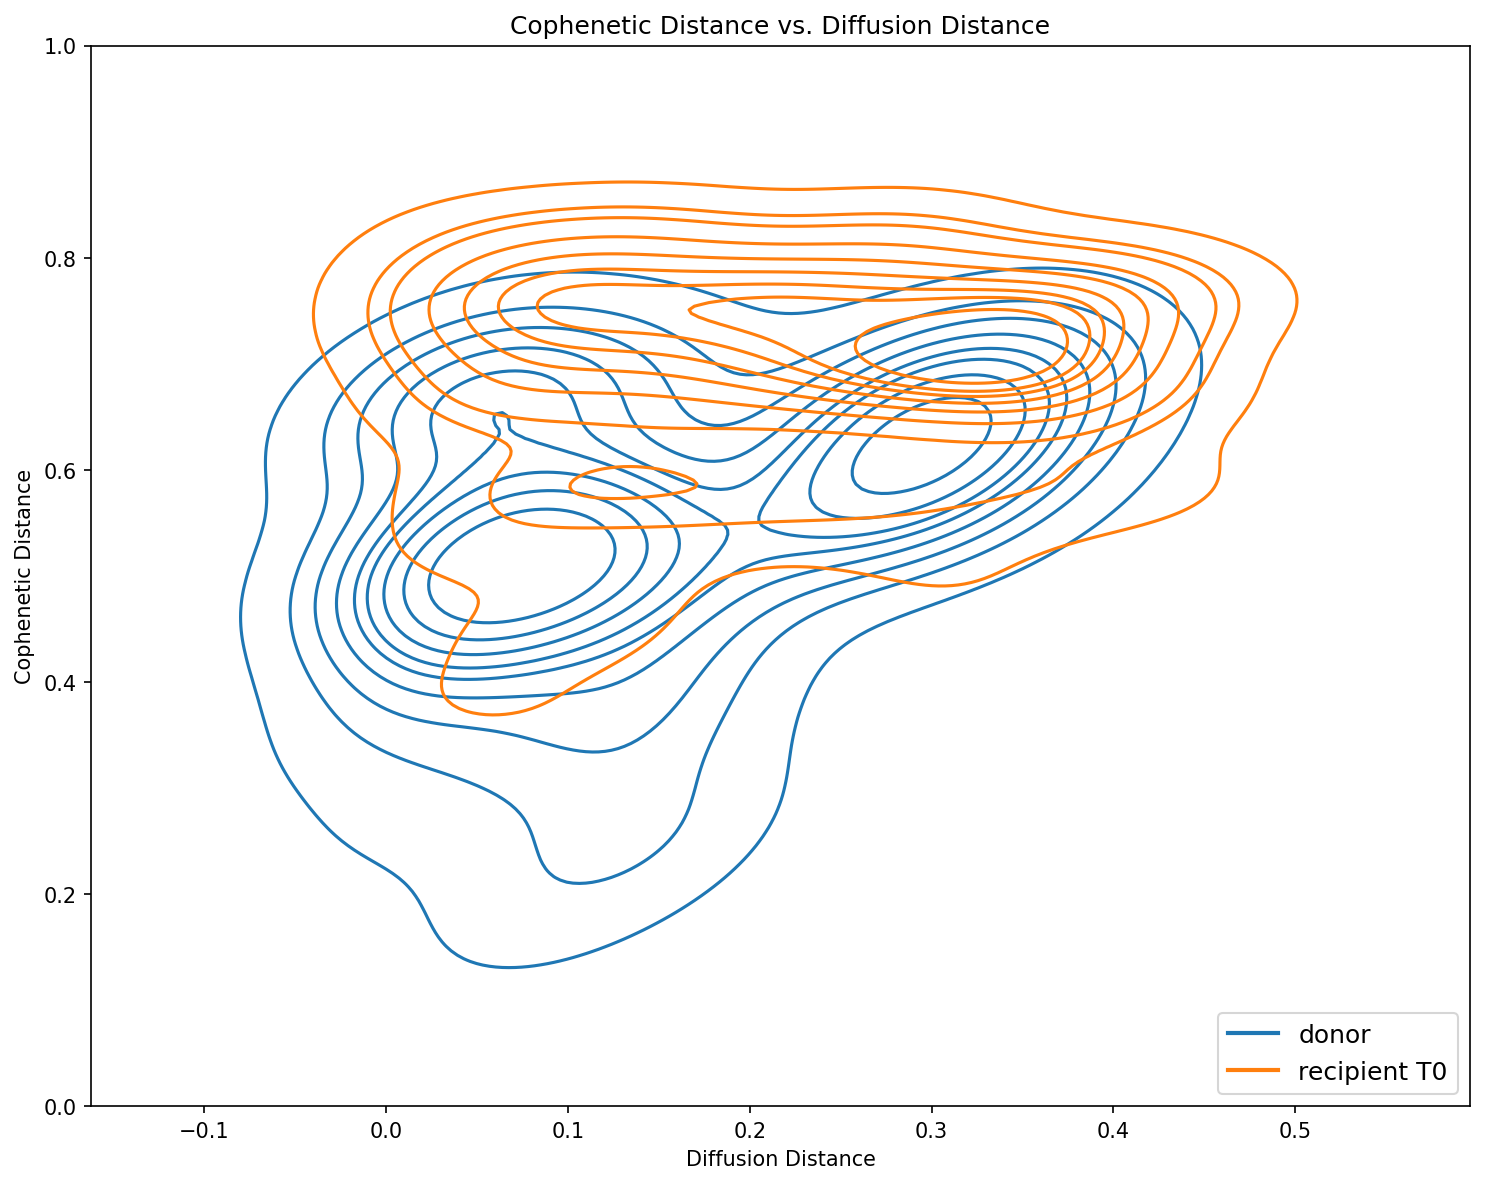

In [25]:
pairs_sub = subset_samples_to_plot(['donor', 'recipient T0'])

In [29]:
def _polygon_area_shoelace(xy: np.ndarray) -> float:
    """
    Compute area of a closed polygon given vertices (N,2) using the shoelace formula.
    This is the discrete form of Green's theorem for area.
    """
    x = xy[:, 0]
    y = xy[:, 1]
    # roll arrays by -1 so (x_{k+1}, y_{k+1}) is aligned with (x_k, y_k)
    x_next = np.roll(x, -1)
    y_next = np.roll(y, -1)
    return 0.5 * np.abs(np.sum(x * y_next - x_next * y))

def kde_hdr_area(
    df: pd.DataFrame,
    x_col: str = "diffusion_distance",
    y_col: str = "cophenetic_distance",
    alpha: float = 0.90,
    gridsize: int = 512,
    pad_frac: float = 0.05,
    bw_method=None,   # e.g. "scott", "silverman", or a float like 0.5
    return_debug: bool = False,
):
    """
    Compute the geometric area of the Highest Density Region (HDR) that contains
    a fixed probability mass alpha under a 2D KDE.

    Returns:
      area_alpha: float
      (optional) debug dict: grid, density, threshold, contours, mass_check
    """
    # ---- 1) Extract points (x,y) from the dataframe ----
    xy = df[[x_col, y_col]].dropna().to_numpy()
    if xy.shape[0] < 5:
        raise ValueError("Not enough points after dropping NaNs to estimate a 2D KDE.")

    x = xy[:, 0]
    y = xy[:, 1]

    # ---- 2) Define a grid that covers the data (with padding) ----
    x_min, x_max = np.min(x), np.max(x)
    y_min, y_max = np.min(y), np.max(y)

    # padding as a fraction of data range to avoid clipping contours at the boundary
    x_pad = pad_frac * (x_max - x_min) if x_max > x_min else 1.0
    y_pad = pad_frac * (y_max - y_min) if y_max > y_min else 1.0

    x_grid = np.linspace(x_min - x_pad, x_max + x_pad, gridsize)
    y_grid = np.linspace(y_min - y_pad, y_max + y_pad, gridsize)

    dx = x_grid[1] - x_grid[0]
    dy = y_grid[1] - y_grid[0]

    X, Y = np.meshgrid(x_grid, y_grid, indexing="xy")

    # ---- 3) Fit a 2D KDE and evaluate it on the grid ----
    # gaussian_kde expects shape (d, n). Here d=2, n=#points.
    kde = gaussian_kde(xy.T, bw_method=bw_method)

    # Evaluate KDE at all grid points (flatten, evaluate, then reshape back)
    grid_points = np.vstack([X.ravel(), Y.ravel()])  # shape (2, gridsize^2)
    Z = kde(grid_points).reshape(gridsize, gridsize)  # density on grid

    # ---- 4) Convert density grid into probability mass per grid cell ----
    # Approximate probability mass in each cell ~ density * dx * dy
    mass_grid = Z * dx * dy
    total_mass = float(np.sum(mass_grid))  # should be close to 1 if grid covers enough
    if total_mass <= 0:
        raise RuntimeError("KDE mass on grid is non-positive; check your data/grid.")

    # Normalize just in case grid doesn't capture exactly all mass
    mass_grid /= total_mass

    # ---- 5) Find density threshold c_alpha that yields mass alpha in the HDR ----
    # HDR = { (x,y) : density >= c_alpha } with total enclosed mass = alpha
    Z_flat = Z.ravel()
    m_flat = mass_grid.ravel()

    # Sort cells by density descending
    order = np.argsort(Z_flat)[::-1]
    Z_sorted = Z_flat[order]
    m_sorted = m_flat[order]

    cum_mass = np.cumsum(m_sorted)
    # index where cumulative mass first reaches/exceeds alpha
    k = int(np.searchsorted(cum_mass, alpha))
    if k >= len(Z_sorted):
        k = len(Z_sorted) - 1

    c_alpha = float(Z_sorted[k])

    # mass check: actual mass included by threshold on the grid
    included = Z_flat >= c_alpha
    mass_check = float(np.sum(m_flat[included]))

    # ---- 6) Extract contour(s) at level c_alpha and compute area(s) ----
    # We use matplotlib's contour extraction to get the vertex paths.
    fig = plt.figure()
    try:
        cs = plt.contour(X, Y, Z, levels=[c_alpha])
        areas = []
        contours_xy = []

        # cs.allsegs[0] is a list of (Ni,2) arrays, one per contour loop
        for seg in cs.allsegs[0]:
            if seg.shape[0] < 3:
                continue
            # Ensure the polygon is treated as closed (shoelace uses roll; closure implicit)
            area = _polygon_area_shoelace(seg)
            areas.append(area)
            contours_xy.append(seg)

        area_alpha = float(np.sum(areas))
    finally:
        plt.close(fig)

    if return_debug:
        debug = {
            "x_grid": x_grid,
            "y_grid": y_grid,
            "X": X,
            "Y": Y,
            "Z_density": Z,
            "c_alpha": c_alpha,
            "mass_check": mass_check,
            "total_mass_before_norm": total_mass,
            "contours": contours_xy,
            "areas_per_contour": areas,
        }
        return area_alpha, debug

    return area_alpha


In [37]:
area95_donor = kde_hdr_area(pairs_sub[(pairs_sub['group_i'] == 'donor') & (pairs_sub['group_j'] == 'donor')], 
                      x_col="diffusion_distance", 
                      y_col="cophenetic_distance", 
                      alpha=0.95,
                      gridsize=256,
                      pad_frac=0.1,
                      bw_method="scott",
                      return_debug=False)
print(area95_donor)

area95_recipient = kde_hdr_area(pairs_sub[(pairs_sub['group_i'] == 'recipient T0') & (pairs_sub['group_j'] == 'recipient T0')],
                        x_col="diffusion_distance", 
                        y_col="cophenetic_distance", 
                        alpha=0.95,
                        gridsize=256,
                        pad_frac=0.1,
                        bw_method="scott",
                        return_debug=False)
print(area95_recipient)


0.054069893154266135
0.17047175282448598


In [2]:
DonorRecipientMapping = pd.read_csv('../raw/DonorRecipientMapping.csv')
DonorRecipientMapping['donor'] = DonorRecipientMapping['donor'].str.split('_').str[0]
DonorRecipientMapping['recipient'] = DonorRecipientMapping['recipient'].str.split('_').str[0]
res = load_results('../models/res_western.zip')
res_openbiome = load_results('../openbiome_models/res_western_openbiome.zip')

donors = DonorRecipientMapping['donor'].unique().tolist()
recipients_t6 = DonorRecipientMapping['recipient'].str.replace('-0', '-6').tolist()
recipients_t0 = [recipient.replace('-6', '-0') for recipient in recipients_t6]
all_samples = set(donors+recipients_t0+recipients_t6)
growth_rates = res.growth_rates
exchanges = res.exchanges
model_samples = set(growth_rates['sample_id'].unique().tolist())
samples = model_samples.intersection(all_samples)

group_labels = pd.DataFrame(samples, columns=['sample'])
group_labels['type'] = group_labels['sample'].apply(lambda x: 'donor' if x.startswith('D') else 'recipient T0' if x.endswith('-0') else 'recipient T6')
T6_mapping = {row['recipient'].replace('-0', '-6'): row['clinical_response'] for _, row in DonorRecipientMapping.iterrows()}
DonorRecipientMapping_t6 = pd.DataFrame({
    'recipient': list(T6_mapping.keys()),
    'clinical_response': list(T6_mapping.values())
})
group_labels = group_labels.merge(DonorRecipientMapping_t6, left_on='sample', right_on='recipient', how='left')
group_labels['clinical_response'] = group_labels['clinical_response'].fillna(group_labels['type'])
group_labels.set_index('sample', inplace=True)
group_labels = group_labels['clinical_response']

openbiome_labels = res_openbiome.growth_rates[['sample_id']].drop_duplicates().copy()
openbiome_labels['clinical_response'] = 'openbiome donor'
group_labels = pd.concat([group_labels, openbiome_labels.set_index('sample_id')['clinical_response']])
group_labels

/opt/anaconda3/envs/qiime2/lib/python3.9/site-packages/micom/workflows/results.py:55: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  tab = pd.read_csv(zippy.open(f"{attr}.csv", "r"))
/opt/anaconda3/envs/qiime2/lib/python3.9/site-packages/micom/workflows/results.py:55: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  tab = pd.read_csv(zippy.open(f"{attr}.csv", "r"))


D-6Fresk                donor
59-6                responder
37-0             recipient T0
22-0             recipient T0
23-0             recipient T0
                   ...       
SRR9224411    openbiome donor
SRR9224225    openbiome donor
SRR9224152    openbiome donor
SRR9224407    openbiome donor
SRR9224057    openbiome donor
Name: clinical_response, Length: 143, dtype: object

In [3]:
# net export at community level
res_production_rates = production_rates(res)[['sample_id', 'metabolite', 'flux', 'name']]
res_production_rates = res_production_rates.pivot_table(
    index='sample_id',
    columns='metabolite',
    values='flux',
    fill_value=0
)
res_production_rates

metabolite,12dhchol[e],12ppd_S[e],13ppd[e],15dap[e],26dap_M[e],2ddglcn[e],2hyoxplac[e],2mbut[e],2obut[e],2omfuc[e],...,tyr_L[e],uchol[e],ura[e],urea[e],uri[e],val_L[e],xan[e],xtsn[e],xyl_D[e],zn2[e]
sample_id,,,,,,,,,,,,,,,,,,,,,
11-0,7.975221,3.375456,1.847474e-04,1.359500e-07,0.294599,0.000000,5.172696e-04,4.129050e-04,0.465602,0.000000e+00,...,0.024168,0.048566,1.788128,0.214267,1.762875,0.059552,0.506643,0.000428,0.024415,1.120282e-07
11-6,0.837275,1.394086,8.385879e-05,1.074828e-01,0.287066,0.002149,3.932580e-04,0.000000e+00,1.335337,3.267716e-08,...,0.002023,0.029898,2.232154,0.595709,4.715256,0.105737,0.462017,0.188267,0.020345,0.000000e+00
12-0,6.338507,4.555480,2.027652e-05,0.000000e+00,0.436618,0.000000,1.643150e-04,1.305549e-05,1.495351,0.000000e+00,...,0.009789,0.322848,3.609042,0.417360,2.475456,0.093668,0.603270,0.000077,0.000017,0.000000e+00
12-6,2.651151,4.326855,1.464855e-07,3.129880e-03,0.495796,0.000001,1.646221e-06,9.790250e-08,1.039953,0.000000e+00,...,0.003142,0.099258,2.280289,0.272515,1.548265,0.097800,0.940241,0.003492,0.000183,0.000000e+00
16-0,8.055237,2.732602,1.701166e-04,1.318989e-07,0.296586,0.000000,4.439993e-04,3.328859e-04,0.418067,0.000000e+00,...,0.024234,0.057108,1.786081,0.234937,1.758630,0.059146,0.503557,0.000375,0.021040,1.145066e-07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
D-6Fresk,2.297128,4.994081,6.687041e-07,4.122893e-03,0.292520,0.001674,1.749795e-10,0.000000e+00,2.943972,0.000000e+00,...,0.002314,0.015965,2.147408,1.166407,8.327136,0.113278,0.468233,0.002886,0.031079,0.000000e+00
D-6Fryst,0.783789,0.071778,0.000000e+00,0.000000e+00,0.190261,0.000000,0.000000e+00,0.000000e+00,6.891759,0.000000e+00,...,0.000168,0.018973,2.130726,1.667811,10.865575,0.113740,0.350561,0.000000,0.020475,0.000000e+00
D-7Fryst,1.161892,0.045183,1.114778e-06,6.097897e-04,0.151313,0.000865,1.186137e-09,0.000000e+00,3.945898,0.000000e+00,...,0.001174,0.008703,1.467830,1.418701,8.762612,0.107250,0.295007,0.000006,0.021891,0.000000e+00


In [4]:
res_production_rates_openbiome = production_rates(res_openbiome)[['sample_id', 'metabolite', 'flux', 'name']]
res_production_rates_openbiome = res_production_rates_openbiome.pivot_table(
    index='sample_id',
    columns='metabolite',
    values='flux',
    fill_value=0
) 

In [5]:
# net export and import at taxon level
def flux_by_taxon(res, direction="export", threshold=0):
    df = (
        res.exchanges
        .query('direction == @direction and taxon != "medium"')
        .assign(flux=lambda x: x['flux'] * x['abundance'])
    )
    df['flux'] = df['flux'].where(df['flux'].abs() > threshold, 0)
    agg = (
        df
        .groupby(['sample_id', 'taxon', 'metabolite'], as_index=False)['flux']
        .sum()
    )
    s2i = {s: i for i, s in enumerate(agg['sample_id'].unique())}
    t2i = {t: i for i, t in enumerate(agg['taxon'].unique())}
    m2i = {m: i for i, m in enumerate(agg['metabolite'].unique())}

    flux_tensor = np.zeros((len(s2i), len(t2i), len(m2i)))
    for _, row in agg.iterrows():
        if row['flux'] == 0: # skip zero fluxes to save time
            continue 
        si = s2i[row['sample_id']]
        ti = t2i[row['taxon']]
        mi = m2i[row['metabolite']]
        flux_tensor[si, ti, mi] += row['flux']
    
    return flux_tensor, s2i, t2i, m2i

export_tensor, s2i, t2i, m2i = flux_by_taxon(res, direction="export", threshold=0)     
export_tensor

array([[[2.86672940e-01, 1.42977617e-07, 2.74209063e-06, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [2.89131882e-01, 1.41648663e-07, 2.82607846e-06, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        ...,
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00]],

       [[8.94688738e-02, 7.72912231e-09, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [1.31164729e-01, 8.63041207e-09, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 

In [6]:
def niche_breadth(res_export, threshold=0):
    res_export = res_export.copy()
    res_export = res_export.where(res_export.abs() > threshold, 0)
    presence_absence = (res_export != 0).astype(int)
    df = pd.DataFrame(index=res_export.index, columns=['niche_breadth'])
    df['niche_breadth'] = presence_absence.sum(axis=1)
    return df

niche_breadth_df = niche_breadth(res_production_rates, threshold=1e-2)
niche_breadth_df = niche_breadth_df.merge(group_labels, left_index=True, right_index=True)
niche_breadth_df

,niche_breadth,clinical_response
11-0,119,recipient T0
11-6,119,responder
12-0,109,recipient T0
12-6,111,non-responder
16-0,115,recipient T0
16-6,117,responder
18-0,126,recipient T0
18-6,125,non-responder
19-0,107,recipient T0
19-6,119,responder


In [7]:
niche_breadth_df_openbiome = niche_breadth(res_production_rates_openbiome, threshold=1e-2)
niche_breadth_df_openbiome = niche_breadth_df_openbiome.merge(openbiome_labels.set_index('sample_id'), left_index=True, right_index=True)
niche_breadth_df_openbiome

,niche_breadth,clinical_response
sample_id,,
SRR9224007,108,openbiome donor
SRR9224009,104,openbiome donor
SRR9224011,101,openbiome donor
SRR9224013,106,openbiome donor
SRR9224015,104,openbiome donor
...,...,...
SRR9224550,103,openbiome donor
SRR9224553,106,openbiome donor
SRR9224555,115,openbiome donor


In [8]:
niche_breadth_combined = pd.concat([niche_breadth_df, niche_breadth_df_openbiome])
niche_breadth_combined

,niche_breadth,clinical_response
11-0,119,recipient T0
11-6,119,responder
12-0,109,recipient T0
12-6,111,non-responder
16-0,115,recipient T0
...,...,...
SRR9224550,103,openbiome donor
SRR9224553,106,openbiome donor
SRR9224555,115,openbiome donor
SRR9224557,106,openbiome donor


p-value annotation legend:
ns: 5.00e-02 < p <= 1.00e+00
*: 1.00e-02 < p <= 5.00e-02
**: 1.00e-03 < p <= 1.00e-02
***: 1.00e-04 < p <= 1.00e-03
****: p <= 1.00e-04

non-responder v.s. donor: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=1.917e-01 U_stat=5.750e+01
donor v.s. openbiome donor: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=8.519e-01 U_stat=6.165e+02
responder v.s. donor: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=2.216e-03 U_stat=1.515e+02
recipient T0 v.s. donor: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=2.923e-02 U_stat=2.505e+02


/opt/anaconda3/envs/qiime2/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/qiime2/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/qiime2/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


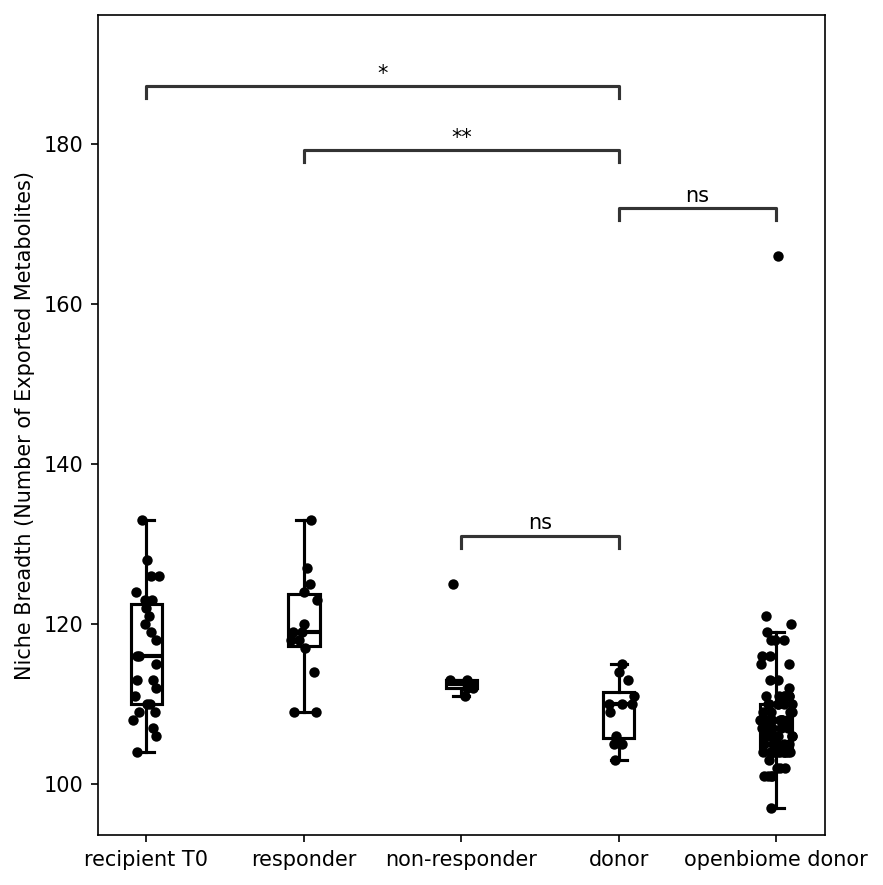

In [9]:
# black and white kwargs
KWARGS = {
    'linewidth': 1.5,
    'boxprops': {'edgecolor': 'black', 'facecolor': 'white', 'linewidth': 1.5},
    'medianprops': {'color': 'black', 'linewidth': 2},
    'whiskerprops': {'color': 'black', 'linewidth': 1.5},
    'capprops': {'color': 'black', 'linewidth': 1.5},
}

plt.figure(figsize=(6, 6), dpi=150)
bp = sns.boxplot(
    data=niche_breadth_combined, 
    x='clinical_response', y='niche_breadth',
    showfliers=False,
    width=0.2,
    **KWARGS
)
sns.stripplot(
    data=niche_breadth_combined,
    x='clinical_response', y='niche_breadth',
    color='black',
    size=5,
    jitter=True,
)

add_stat_annotation(
    ax=bp,
    data=niche_breadth_combined,
    x='clinical_response',
    y='niche_breadth',
    box_pairs=[
        ('donor', 'recipient T0'),
        ('donor', 'responder'),
        ('donor', 'non-responder'),
        ('donor', 'openbiome donor'),
    ],
    test='Mann-Whitney',
    text_format='star',
    loc='inside',
    verbose=2
)
plt.xlabel('')
plt.ylabel('Niche Breadth (Number of Exported Metabolites)')
plt.tight_layout()
plt.show()

/opt/anaconda3/envs/qiime2/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/qiime2/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/qiime2/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/qiime2/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future ver

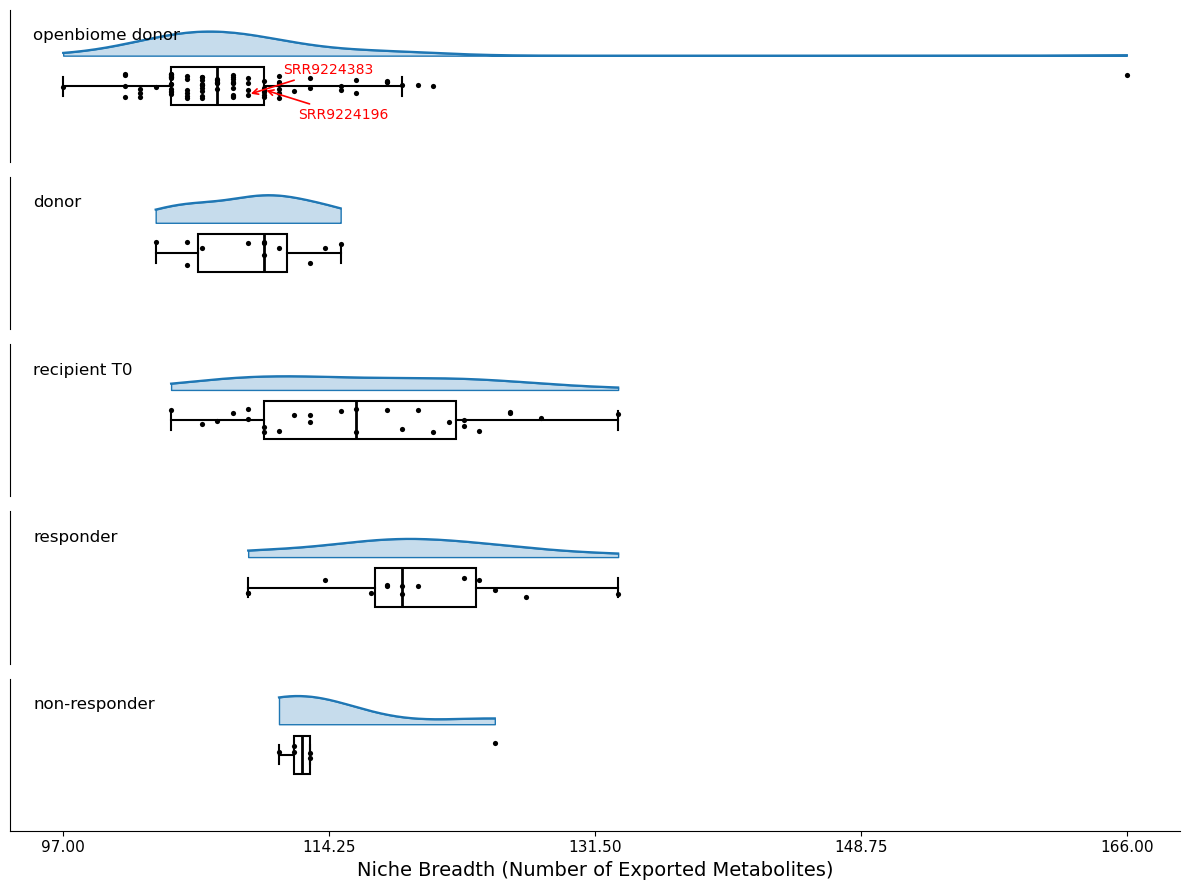

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# 0) Aesthetic controls (tune these)
# -----------------------------
group_order = ["openbiome donor", "donor", "recipient T0", "responder", "non-responder"]

# Controls the *panel* size (bigger height = more y-space per ridge)
FACET_HEIGHT = 1.6    # was ~1.6
FACET_ASPECT = 4.5

# Controls the *ridge* size (scales density curve vertically)
RIDGE_Y_SCALE = 2.1   # >1 makes KDE taller; try 1.4–2.2

# Ridge overlap (more negative = more overlap)
HSPACE = 0.7        # was ~-0.35; less overlap makes panels clearer

# Where to place box/points baseline (in data y-units)
BOX_Y = -0.2
BOX_HEIGHT = 0.25
POINT_Y = -0.2
POINT_JITTER = 0.08

# KDE smoothing
BW_ADJUST = 1.0

SCATTER_SIZE = 14
ANNOTATE_IDS = {"SRR9224383", "SRR9224196"}
ANNOTATE_GROUP = "openbiome donor"
sample_id_col = "sample_id"
# -----------------------------
# 1) Subset + categorical order
# -----------------------------
plot_df = niche_breadth_combined[
    niche_breadth_combined["clinical_response"].isin(group_order)
].copy()

plot_df["clinical_response"] = pd.Categorical(
    plot_df["clinical_response"], categories=group_order, ordered=True
)
plot_df = plot_df.reset_index().rename(columns={"index":"sample_id"})

# -----------------------------
# 2) Ridge plot with FacetGrid
# -----------------------------
g = sns.FacetGrid(
    plot_df,
    row="clinical_response",
    row_order=group_order,
    height=FACET_HEIGHT,
    aspect=FACET_ASPECT,
    sharex=True,
    sharey=True,
    despine=False,   # keep spines controllable
)
g.fig.set_size_inches(12, 9)
# Filled KDE (ridge body)
g.map_dataframe(
    sns.kdeplot,
    x="niche_breadth",
    fill=True,
    bw_adjust=BW_ADJUST,
    cut=0,
    clip_on=False,
)

# Outline KDE (ridge edge)
g.map_dataframe(
    sns.kdeplot,
    x="niche_breadth",
    fill=False,
    bw_adjust=BW_ADJUST,
    cut=0,
    clip_on=False,
    linewidth=1.6,
)

# -----------------------------
# 3) Scale KDE vertically (make the ridge taller)
#    We multiply the y-values of every KDE line by RIDGE_Y_SCALE.
# -----------------------------
for ax in g.axes.flat:
    for line in ax.lines:
        xdata = line.get_xdata()
        ydata = line.get_ydata()
        line.set_data(xdata, ydata * RIDGE_Y_SCALE)

    # Filled KDE is stored in PolyCollections; scale their vertices too
    for coll in ax.collections:
        # Some collections won't have paths; guard for safety
        paths = getattr(coll, "get_paths", lambda: [])()
        for p in paths:
            v = p.vertices
            v[:, 1] *= RIDGE_Y_SCALE

# -----------------------------
# 4) Overlay horizontal box + points in each ridge panel
# -----------------------------
# Matplotlib-style boxplot kwargs (NO top-level "linewidth")
KWARGS = {
    "boxprops": {"edgecolor": "black", "facecolor": "white", "linewidth": 1.5},
    "medianprops": {"color": "black", "linewidth": 2.0},
    "whiskerprops": {"color": "black", "linewidth": 1.5},
    "capprops": {"color": "black", "linewidth": 1.5},
}

rng = np.random.default_rng(0)

for ax, grp in zip(g.axes.flat, group_order):
    # Subset to this group
    sub = plot_df.loc[plot_df["clinical_response"] == grp].copy()

    # --- Boxplot uses all x values (same as before) ---
    x = sub["niche_breadth"].dropna().values
    ax.boxplot(
        [x],
        vert=False,
        positions=[BOX_Y],
        widths=BOX_HEIGHT,
        showfliers=False,
        patch_artist=True,
        **KWARGS,
    )

    # --- Scatter points with deterministic jitter stored in the DataFrame ---
    sub = sub.dropna(subset=["niche_breadth"]).copy()

    # IMPORTANT: ensure sub has sample IDs available
    # If your sample IDs are the index, use: sub = sub.reset_index().rename(columns={"index":"sample_id"})
    # Otherwise, set sample_id_col to your actual column name.
    # sample_id_col = "sample_id"  # <-- change this if your column is named differently

    sub["_jy"] = POINT_Y + rng.uniform(-POINT_JITTER, POINT_JITTER, size=len(sub))

    ax.scatter(
        sub["niche_breadth"].to_numpy(),
        sub["_jy"].to_numpy(),
        s=SCATTER_SIZE,
        c="black",
        linewidths=0,
        zorder=3,
    )

    # --- Annotate specific OpenBiome donors with arrows ---
    if grp == ANNOTATE_GROUP and sample_id_col in sub.columns:
        ann = sub[sub[sample_id_col].isin(ANNOTATE_IDS)]

        # Two slightly different text offsets so labels don't overlap
        offsets = {
            "SRR9224383": (25, 18),
            "SRR9224196": (25, -18),
        }

        for _, r in ann.iterrows():
            sid = r[sample_id_col]
            dx, dy = offsets.get(sid, (25, 15))

            ax.annotate(
                sid,
                xy=(r["niche_breadth"], r["_jy"]),      # point location
                xytext=(dx, dy),                         # text offset (points)
                textcoords="offset points",
                ha="left",
                va="center",
                fontsize=10,
                color="red",
                arrowprops=dict(arrowstyle="->", lw=1.2, color="red"),
                zorder=4,
            )

# -----------------------------
# 5) Restore y-axis (Density) + improve label placement
# -----------------------------
# Remove default facet titles and add cleaner in-panel labels
g.set_titles("")  # removes seaborn's default "clinical_response = ..."

for i, (ax, grp) in enumerate(zip(g.axes.flat, group_order)):
    # In-panel group label
    ax.text(
        0.02, 0.88, grp,
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=12,
        color="black",
    )

    # --- Y-axis cleanup ---
    ax.set_ylabel("")                 # remove "Density"
    ax.set_yticks([])                 # remove tick marks
    ax.set_yticklabels([])            # remove numbers

    ax.spines["left"].set_visible(True)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)

    # --- X-axis handling ---
    if i < len(group_order) - 1:
        # Hide x-axis for all but bottom panel
        ax.spines["bottom"].set_visible(False)
        ax.set_xlabel("")
        ax.tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False)
        ax.set_xticks([])
    else:
        # Bottom panel: show x-axis
        ax.spines["bottom"].set_visible(True)
        xmin = plot_df["niche_breadth"].min()
        xmax = plot_df["niche_breadth"].max()
        ax.set_xticks(np.linspace(xmin, xmax, 5))
        ax.tick_params(axis="x", labelsize=11)

    # Ensure box/points baseline is visible
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(min(ymin, BOX_Y - 0.10), ymax)

# Global x-axis label
g.set_xlabels("Niche Breadth (Number of Exported Metabolites)", fontsize=14)

# Panel spacing
g.fig.subplots_adjust(hspace=HSPACE)
plt.tight_layout()
plt.show()

In [22]:
def niche_effectiveness(res_export, threshold=0):
    res_export = res_export.copy()

    res_export = res_export.transpose() # metabolite x sample
    # compute shannon diversity for each sample
    p = res_export / res_export.sum(axis=0)
    shannon_diversity = -(p * np.log(p.where(p > threshold, 1.0))).sum(axis=0)
    df = pd.DataFrame(index=res_export.columns, columns=['niche_effectiveness'])
    df['niche_effectiveness'] = shannon_diversity
    return df

niche_effectiveness_df = niche_effectiveness(res_production_rates, threshold=1e-2)
niche_effectiveness_df = niche_effectiveness_df.merge(group_labels, left_index=True, right_index=True)
niche_effectiveness_df_openbiome = niche_effectiveness(res_production_rates_openbiome, threshold=1e-2)
niche_effectiveness_df_openbiome = niche_effectiveness_df_openbiome.merge(openbiome_labels.set_index('sample_id'), left_index=True, right_index=True)
niche_effectiveness_combined = pd.concat([niche_effectiveness_df, niche_effectiveness_df_openbiome])
niche_effectiveness_combined

,niche_effectiveness,clinical_response
11-0,2.465195,recipient T0
11-6,2.855648,responder
12-0,2.721791,recipient T0
12-6,2.373481,non-responder
16-0,2.492961,recipient T0
...,...,...
SRR9224550,2.869248,openbiome donor
SRR9224553,2.822756,openbiome donor
SRR9224555,2.942941,openbiome donor
SRR9224557,2.942380,openbiome donor


p-value annotation legend:
ns: 5.00e-02 < p <= 1.00e+00
*: 1.00e-02 < p <= 5.00e-02
**: 1.00e-03 < p <= 1.00e-02
***: 1.00e-04 < p <= 1.00e-03
****: p <= 1.00e-04

non-responder v.s. donor: t-test independent samples with Bonferroni correction, P_val=8.113e-05 stat=-5.952e+00
donor v.s. openbiome donor: t-test independent samples with Bonferroni correction, P_val=3.909e-02 stat=2.638e+00
responder v.s. donor: t-test independent samples with Bonferroni correction, P_val=3.356e-02 stat=-2.872e+00
recipient T0 v.s. donor: t-test independent samples with Bonferroni correction, P_val=1.271e-04 stat=-4.736e+00


/opt/anaconda3/envs/qiime2/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/qiime2/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/qiime2/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


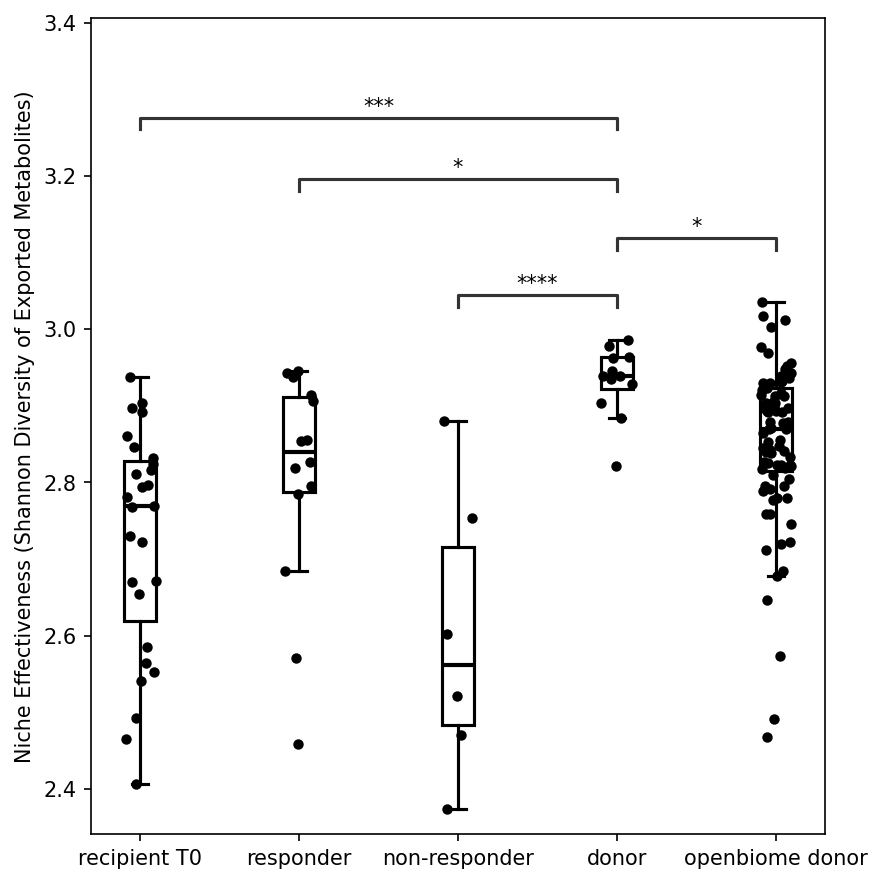

In [23]:
# repeat the boxplot for niche effectiveness
plt.figure(figsize=(6, 6), dpi=150)
bp = sns.boxplot(
    data=niche_effectiveness_combined, 
    x='clinical_response', y='niche_effectiveness',
    showfliers=False,
    width=0.2,
    **KWARGS
)
sns.stripplot(
    data=niche_effectiveness_combined,
    x='clinical_response', y='niche_effectiveness',
    color='black',
    size=5,
    jitter=True,
)

add_stat_annotation(
    ax=bp,
    data=niche_effectiveness_combined,
    x='clinical_response',
    y='niche_effectiveness',
    box_pairs=[
        ('donor', 'recipient T0'),
        ('donor', 'responder'),
        ('donor', 'non-responder'),
        ('donor', 'openbiome donor'),
    ],
    test='t-test_ind',
    text_format='star',
    loc='inside',
    verbose=2
)
plt.xlabel('')
plt.ylabel('Niche Effectiveness (Shannon Diversity of Exported Metabolites)')
plt.tight_layout()
plt.show()

/opt/anaconda3/envs/qiime2/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/qiime2/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/qiime2/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/qiime2/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future ver

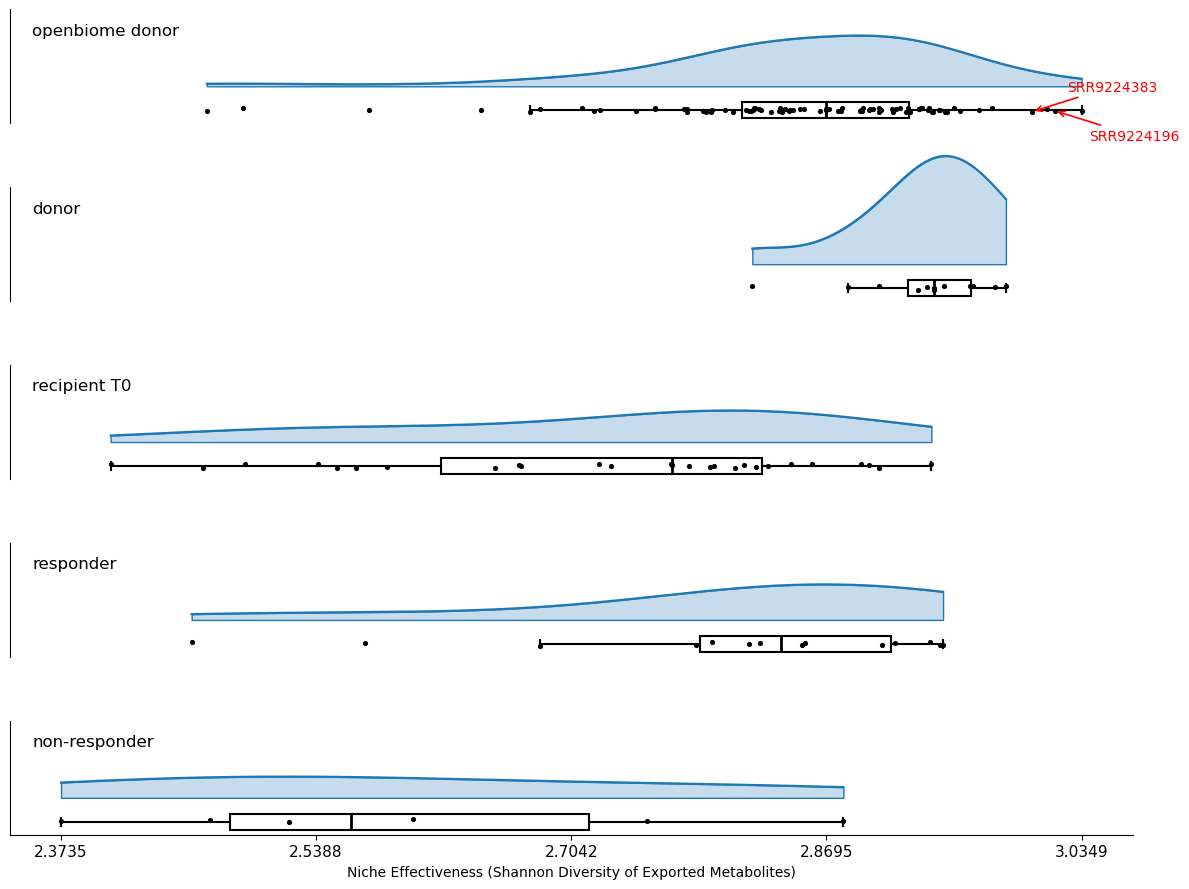

In [34]:
# -----------------------------
# 0) Aesthetic controls (tune these)
# -----------------------------
group_order = ["openbiome donor", "donor", "recipient T0", "responder", "non-responder"]

# Controls the *panel* size (bigger height = more y-space per ridge)
FACET_HEIGHT = 1.6    # was ~1.6
FACET_ASPECT = 4.5

# Controls the *ridge* size (scales density curve vertically)
RIDGE_Y_SCALE = 1.5   # >1 makes KDE taller; try 1.4–2.2

# Ridge overlap (more negative = more overlap)
HSPACE = 0.7        # was ~-0.35; less overlap makes panels clearer

# Where to place box/points baseline (in data y-units)
BOX_Y = -3
BOX_HEIGHT = 2
POINT_Y = -3
POINT_JITTER = 0.3

# KDE smoothing
BW_ADJUST = 1.0

SCATTER_SIZE = 14
ANNOTATE_IDS = {"SRR9224383", "SRR9224196"}
ANNOTATE_GROUP = "openbiome donor"
# -----------------------------
# 1) Subset + categorical order
# -----------------------------
plot_df = niche_effectiveness_combined[
    niche_effectiveness_combined["clinical_response"].isin(group_order)
].copy()

plot_df["clinical_response"] = pd.Categorical(
    plot_df["clinical_response"], categories=group_order, ordered=True
)
plot_df = plot_df.reset_index().rename(columns={"index":"sample_id"})

# -----------------------------
# 2) Ridge plot with FacetGrid
# -----------------------------
g = sns.FacetGrid(
    plot_df,
    row="clinical_response",
    row_order=group_order,
    height=FACET_HEIGHT,
    aspect=FACET_ASPECT,
    sharex=True,
    sharey=True,
    despine=False,   # keep spines controllable
)
g.fig.set_size_inches(12, 9)
# Filled KDE (ridge body)
g.map_dataframe(
    sns.kdeplot,
    x="niche_effectiveness",
    fill=True,
    bw_adjust=BW_ADJUST,
    cut=0,
    clip_on=False,
)

# Outline KDE (ridge edge)
g.map_dataframe(
    sns.kdeplot,
    x="niche_effectiveness",
    fill=False,
    bw_adjust=BW_ADJUST,
    cut=0,
    clip_on=False,
    linewidth=1.6,
)

# -----------------------------
# 3) Scale KDE vertically (make the ridge taller)
#    We multiply the y-values of every KDE line by RIDGE_Y_SCALE.
# -----------------------------
for ax in g.axes.flat:
    for line in ax.lines:
        xdata = line.get_xdata()
        ydata = line.get_ydata()
        line.set_data(xdata, ydata * RIDGE_Y_SCALE)

    # Filled KDE is stored in PolyCollections; scale their vertices too
    for coll in ax.collections:
        # Some collections won't have paths; guard for safety
        paths = getattr(coll, "get_paths", lambda: [])()
        for p in paths:
            v = p.vertices
            v[:, 1] *= RIDGE_Y_SCALE

# -----------------------------
# 4) Overlay horizontal box + points in each ridge panel
# -----------------------------
# Matplotlib-style boxplot kwargs (NO top-level "linewidth")
KWARGS = {
    "boxprops": {"edgecolor": "black", "facecolor": "white", "linewidth": 1.5},
    "medianprops": {"color": "black", "linewidth": 2.0},
    "whiskerprops": {"color": "black", "linewidth": 1.5},
    "capprops": {"color": "black", "linewidth": 1.5},
}

rng = np.random.default_rng(0)

for ax, grp in zip(g.axes.flat, group_order):
    # Subset to this group
    sub = plot_df.loc[plot_df["clinical_response"] == grp].copy()

    # --- Boxplot uses all x values (same as before) ---
    x = sub["niche_effectiveness"].dropna().values
    ax.boxplot(
        [x],
        vert=False,
        positions=[BOX_Y],
        widths=BOX_HEIGHT,
        showfliers=False,
        patch_artist=True,
        **KWARGS,
    )

    # --- Scatter points with deterministic jitter stored in the DataFrame ---
    sub = sub.dropna(subset=["niche_effectiveness"]).copy()

    # IMPORTANT: ensure sub has sample IDs available
    # If your sample IDs are the index, use: sub = sub.reset_index().rename(columns={"index":"sample_id"})
    # Otherwise, set sample_id_col to your actual column name.
    # sample_id_col = "sample_id"  # <-- change this if your column is named differently

    sub["_jy"] = POINT_Y + rng.uniform(-POINT_JITTER, POINT_JITTER, size=len(sub))

    ax.scatter(
        sub["niche_effectiveness"].to_numpy(),
        sub["_jy"].to_numpy(),
        s=SCATTER_SIZE,
        c="black",
        linewidths=0,
        zorder=3,
    )

    # --- Annotate specific OpenBiome donors with arrows ---
    if grp == ANNOTATE_GROUP and sample_id_col in sub.columns:
        ann = sub[sub[sample_id_col].isin(ANNOTATE_IDS)]

        # Two slightly different text offsets so labels don't overlap
        offsets = {
            "SRR9224383": (25, 18),
            "SRR9224196": (25, -18),
        }

        for _, r in ann.iterrows():
            sid = r[sample_id_col]
            dx, dy = offsets.get(sid, (25, 15))

            ax.annotate(
                sid,
                xy=(r["niche_effectiveness"], r["_jy"]),      # point location
                xytext=(dx, dy),                         # text offset (points)
                textcoords="offset points",
                ha="left",
                va="center",
                fontsize=10,
                color="red",
                arrowprops=dict(arrowstyle="->", lw=1.2, color="red"),
                zorder=4,
            )

# -----------------------------
# 5) Restore y-axis (Density) + improve label placement
# -----------------------------
# Remove default facet titles and add cleaner in-panel labels
g.set_titles("")  # removes seaborn's default "clinical_response = ..."

for i, (ax, grp) in enumerate(zip(g.axes.flat, group_order)):
    # In-panel group label
    ax.text(
        0.02, 0.88, grp,
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=12,
        color="black",
    )

    # --- Y-axis cleanup ---
    ax.set_ylabel("")                 # remove "Density"
    ax.set_yticks([])                 # remove tick marks
    ax.set_yticklabels([])            # remove numbers

    ax.spines["left"].set_visible(True)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)

    # --- X-axis handling ---
    if i < len(group_order) - 1:
        # Hide x-axis for all but bottom panel
        ax.spines["bottom"].set_visible(False)
        ax.set_xlabel("")
        ax.tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False)
        ax.set_xticks([])
    else:
        # Bottom panel: show x-axis
        ax.spines["bottom"].set_visible(True)
        xmin = plot_df["niche_effectiveness"].min()
        xmax = plot_df["niche_effectiveness"].max()
        ax.set_xticks(np.linspace(xmin, xmax, 5))
        ax.tick_params(axis="x", labelsize=11)

    # Ensure box/points baseline is visible
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(min(ymin, BOX_Y - 0.10), ymax)

# Global x-axis label
g.set_xlabels("Niche Effectiveness (Shannon Diversity of Exported Metabolites)")

# Panel spacing
g.fig.subplots_adjust(hspace=HSPACE)
plt.tight_layout()
plt.show()

In [35]:
# calculate niche_eveness
niche_evenness_combined = niche_effectiveness_combined.merge(niche_breadth_combined.drop(columns=['clinical_response']), left_index=True, right_index=True)
niche_evenness_combined

,niche_effectiveness,clinical_response,niche_breadth
11-0,2.465195,recipient T0,119
11-6,2.855648,responder,119
12-0,2.721791,recipient T0,109
12-6,2.373481,non-responder,111
16-0,2.492961,recipient T0,115
...,...,...,...
SRR9224550,2.869248,openbiome donor,103
SRR9224553,2.822756,openbiome donor,106
SRR9224555,2.942941,openbiome donor,115
SRR9224557,2.942380,openbiome donor,106


In [36]:
niche_evenness_combined['niche_evenness'] = niche_evenness_combined['niche_effectiveness'] / np.log(niche_evenness_combined['niche_breadth'])
niche_evenness_combined

,niche_effectiveness,clinical_response,niche_breadth,niche_evenness
11-0,2.465195,recipient T0,119,0.515826
11-6,2.855648,responder,119,0.597525
12-0,2.721791,recipient T0,109,0.580173
12-6,2.373481,non-responder,111,0.503974
16-0,2.492961,recipient T0,115,0.525394
...,...,...,...,...
SRR9224550,2.869248,openbiome donor,103,0.619076
SRR9224553,2.822756,openbiome donor,106,0.605295
SRR9224555,2.942941,openbiome donor,115,0.620228
SRR9224557,2.942380,openbiome donor,106,0.630946


p-value annotation legend:
ns: 5.00e-02 < p <= 1.00e+00
*: 1.00e-02 < p <= 5.00e-02
**: 1.00e-03 < p <= 1.00e-02
***: 1.00e-04 < p <= 1.00e-03
****: p <= 1.00e-04

non-responder v.s. donor: t-test independent samples with Bonferroni correction, P_val=2.916e-05 stat=-6.502e+00
donor v.s. openbiome donor: t-test independent samples with Bonferroni correction, P_val=1.359e-01 stat=2.152e+00
responder v.s. donor: t-test independent samples with Bonferroni correction, P_val=1.513e-03 stat=-4.131e+00
recipient T0 v.s. donor: t-test independent samples with Bonferroni correction, P_val=4.797e-05 stat=-5.053e+00


/opt/anaconda3/envs/qiime2/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/qiime2/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/qiime2/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


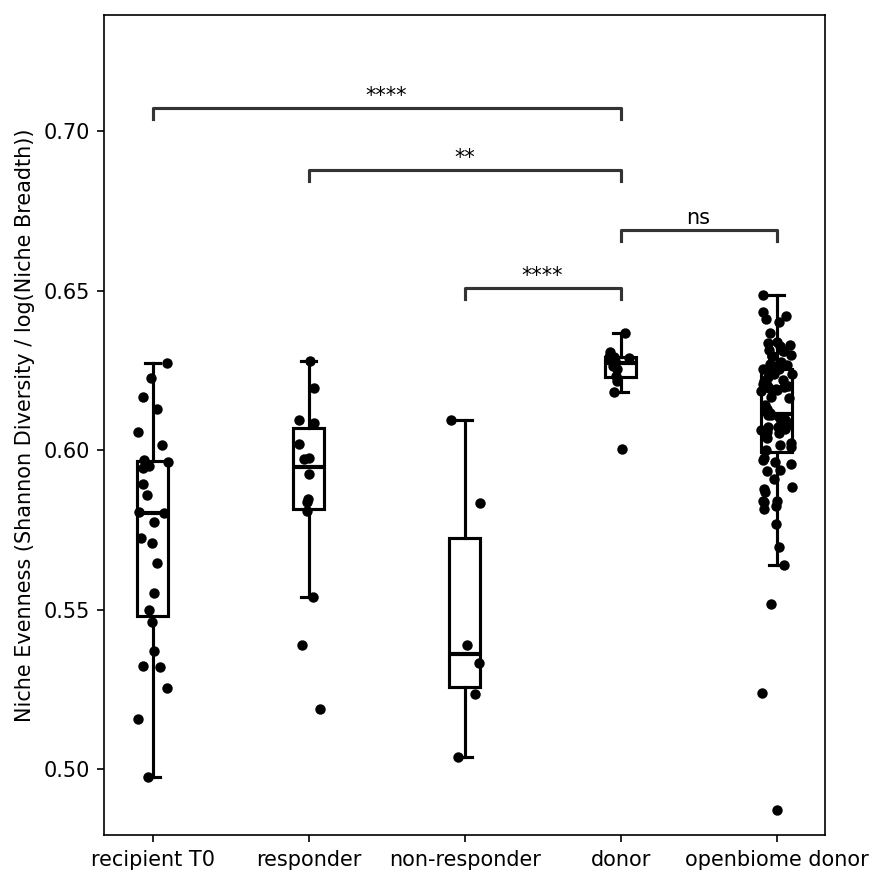

In [37]:
# repeat the boxplot for niche evenness
plt.figure(figsize=(6, 6), dpi=150)
bp = sns.boxplot(
    data=niche_evenness_combined, 
    x='clinical_response', y='niche_evenness',
    showfliers=False,
    width=0.2,
    **KWARGS
)
sns.stripplot(
    data=niche_evenness_combined,
    x='clinical_response', y='niche_evenness',
    color='black',
    size=5,
    jitter=True,
)
add_stat_annotation(
    ax=bp,
    data=niche_evenness_combined,
    x='clinical_response',
    y='niche_evenness',
    box_pairs=[
        ('donor', 'recipient T0'),
        ('donor', 'responder'),
        ('donor', 'non-responder'),
        ('donor', 'openbiome donor'),
    ],
    test='t-test_ind',
    text_format='star',
    loc='inside',
    verbose=2
)
plt.xlabel('')
plt.ylabel('Niche Evenness (Shannon Diversity / log(Niche Breadth))')
plt.tight_layout()
plt.show()  

/opt/anaconda3/envs/qiime2/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/qiime2/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/qiime2/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/qiime2/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future ver

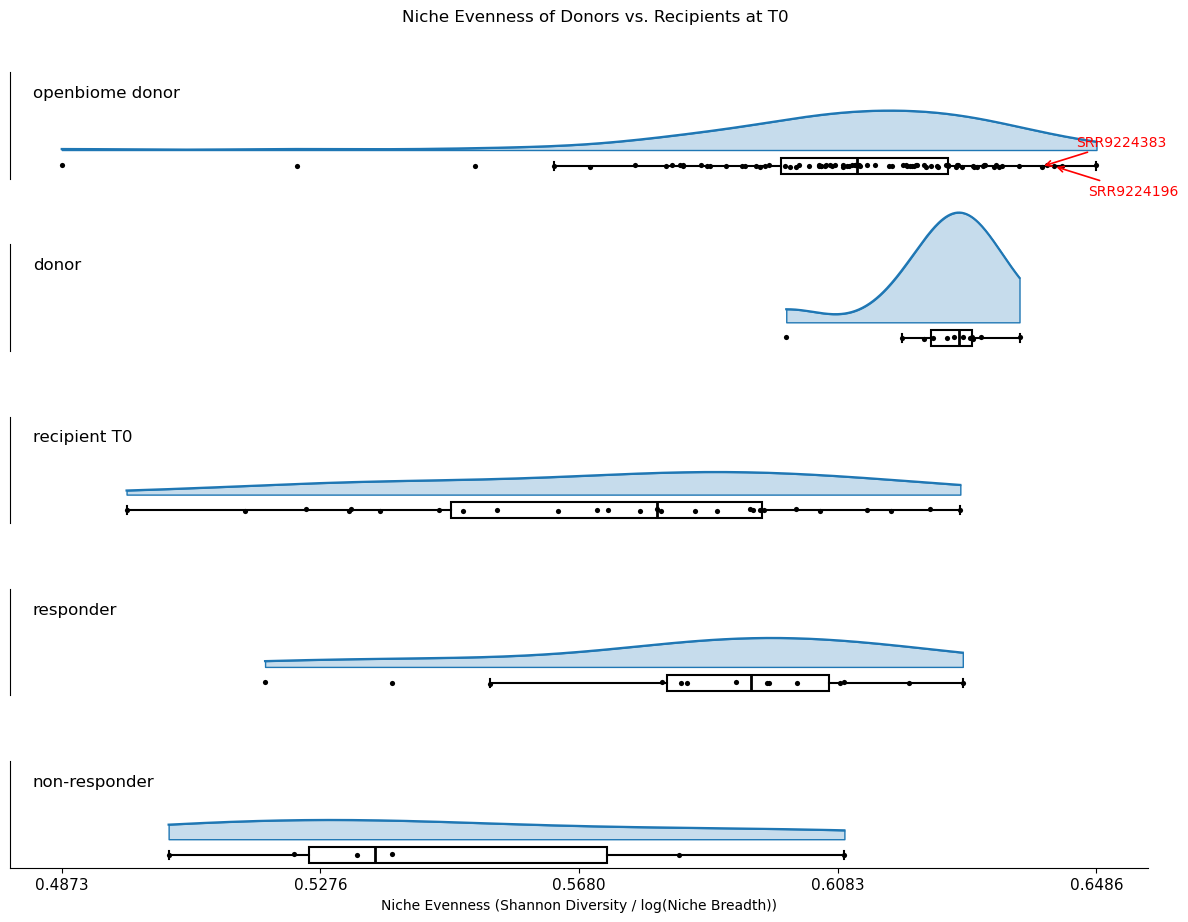

In [44]:
# repeat the kde ridge plot for niche evenness
# -----------------------------
# 0) Aesthetic controls (tune these)
# -----------------------------
group_order = ["openbiome donor", "donor", "recipient T0", "responder", "non-responder"]

# Controls the *panel* size (bigger height = more y-space per ridge)
FACET_HEIGHT = 1.6    # was ~1.6
FACET_ASPECT = 4.5

# Controls the *ridge* size (scales density curve vertically)
RIDGE_Y_SCALE = 1.5   # >1 makes KDE taller; try 1.4–2.2

# Ridge overlap (more negative = more overlap)
HSPACE = 0.7        # was ~-0.35; less overlap makes panels clearer

# Where to place box/points baseline (in data y-units)
BOX_Y = -11
BOX_HEIGHT = 11
POINT_Y = -11
POINT_JITTER = 0.8

# KDE smoothing
BW_ADJUST = 1.0

SCATTER_SIZE = 14
ANNOTATE_IDS = {"SRR9224383", "SRR9224196"}
ANNOTATE_GROUP = "openbiome donor"
# -----------------------------
# 1) Subset + categorical order
# -----------------------------
plot_df = niche_evenness_combined[
    niche_evenness_combined["clinical_response"].isin(group_order)
].copy()

plot_df["clinical_response"] = pd.Categorical(
    plot_df["clinical_response"], categories=group_order, ordered=True
)
plot_df = plot_df.reset_index().rename(columns={"index":"sample_id"})

# -----------------------------
# 2) Ridge plot with FacetGrid
# -----------------------------
g = sns.FacetGrid(
    plot_df,
    row="clinical_response",
    row_order=group_order,
    height=FACET_HEIGHT,
    aspect=FACET_ASPECT,
    sharex=True,
    sharey=True,
    despine=False,   # keep spines controllable
)
g.fig.set_size_inches(12, 9)
# Filled KDE (ridge body)
g.map_dataframe(
    sns.kdeplot,
    x="niche_evenness",
    fill=True,
    bw_adjust=BW_ADJUST,
    cut=0,
    clip_on=False,
)

# Outline KDE (ridge edge)
g.map_dataframe(
    sns.kdeplot,
    x="niche_evenness",
    fill=False,
    bw_adjust=BW_ADJUST,
    cut=0,
    clip_on=False,
    linewidth=1.6,
)

# -----------------------------
# 3) Scale KDE vertically (make the ridge taller)
#    We multiply the y-values of every KDE line by RIDGE_Y_SCALE.
# -----------------------------
for ax in g.axes.flat:
    for line in ax.lines:
        xdata = line.get_xdata()
        ydata = line.get_ydata()
        line.set_data(xdata, ydata * RIDGE_Y_SCALE)

    # Filled KDE is stored in PolyCollections; scale their vertices too
    for coll in ax.collections:
        # Some collections won't have paths; guard for safety
        paths = getattr(coll, "get_paths", lambda: [])()
        for p in paths:
            v = p.vertices
            v[:, 1] *= RIDGE_Y_SCALE

# -----------------------------
# 4) Overlay horizontal box + points in each ridge panel
# -----------------------------
# Matplotlib-style boxplot kwargs (NO top-level "linewidth")
KWARGS = {
    "boxprops": {"edgecolor": "black", "facecolor": "white", "linewidth": 1.5},
    "medianprops": {"color": "black", "linewidth": 2.0},
    "whiskerprops": {"color": "black", "linewidth": 1.5},
    "capprops": {"color": "black", "linewidth": 1.5},
}

rng = np.random.default_rng(0)

for ax, grp in zip(g.axes.flat, group_order):
    # Subset to this group
    sub = plot_df.loc[plot_df["clinical_response"] == grp].copy()

    # --- Boxplot uses all x values (same as before) ---
    x = sub["niche_evenness"].dropna().values
    ax.boxplot(
        [x],
        vert=False,
        positions=[BOX_Y],
        widths=BOX_HEIGHT,
        showfliers=False,
        patch_artist=True,
        **KWARGS,
    )

    # --- Scatter points with deterministic jitter stored in the DataFrame ---
    sub = sub.dropna(subset=["niche_evenness"])

    # IMPORTANT: ensure sub has sample IDs available
    # If your sample IDs are the index, use: sub = sub.reset_index().rename(columns={"index":"sample_id"})
    # Otherwise, set sample_id_col to your actual column name.
    sample_id_col = "sample_id"  # <-- change this if your column is named differently

    sub["_jy"] = POINT_Y + rng.uniform(-POINT_JITTER, POINT_JITTER, size=len(sub))

    ax.scatter(
        sub["niche_evenness"].to_numpy(),
        sub["_jy"].to_numpy(),
        s=SCATTER_SIZE,
        c="black",
        linewidths=0,
        zorder=3,
    )

    # --- Annotate specific OpenBiome donors with arrows ---
    if grp == ANNOTATE_GROUP and sample_id_col in sub.columns:
        ann = sub[sub[sample_id_col].isin(ANNOTATE_IDS)]

        # Two slightly different text offsets so labels don't overlap
        offsets = {
            "SRR9224383": (25, 18),
            "SRR9224196": (25, -18),
        }

        for _, r in ann.iterrows():
            sid = r[sample_id_col]
            dx, dy = offsets.get(sid, (25, 15))

            ax.annotate(
                sid,
                xy=(r["niche_evenness"], r["_jy"]),      # point location
                xytext=(dx, dy),                         # text offset (points)
                textcoords="offset points",
                ha="left",
                va="center",
                fontsize=10,
                color="red",
                arrowprops=dict(arrowstyle="->", lw=1.2, color="red"),
                zorder=4,
            )
# -----------------------------
# 5) Restore y-axis (Density) + improve label placement
# -----------------------------
# Remove default facet titles and add cleaner in-panel labels
g.set_titles("")  # removes seaborn's default "clinical_response = ..."

for i, (ax, grp) in enumerate(zip(g.axes.flat, group_order)):
    # In-panel group label
    ax.text(
        0.02, 0.88, grp,
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=12,
        color="black",
    )

    # --- Y-axis cleanup ---
    ax.set_ylabel("")                 # remove "Density"
    ax.set_yticks([])                 # remove tick marks
    ax.set_yticklabels([])            # remove numbers

    ax.spines["left"].set_visible(True)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)

    # --- X-axis handling ---
    if i < len(group_order) - 1:
        # Hide x-axis for all but bottom panel
        ax.spines["bottom"].set_visible(False)
        ax.set_xlabel("")
        ax.tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False)
        ax.set_xticks([])
    else:
        # Bottom panel: show x-axis
        ax.spines["bottom"].set_visible(True)
        xmin = plot_df["niche_evenness"].min()
        xmax = plot_df["niche_evenness"].max()
        ax.set_xticks(np.linspace(xmin, xmax, 5))
        ax.tick_params(axis="x", labelsize=11)

    # Ensure box/points baseline is visible
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(min(ymin, BOX_Y - 0.10), ymax)

# Global x-axis label
g.set_xlabels("Niche Evenness (Shannon Diversity / log(Niche Breadth))")
# Panel spacing
g.fig.subplots_adjust(hspace=HSPACE)

plt.suptitle("Niche Evenness of Donors vs. Recipients at T0", y=1.02)
plt.tight_layout()
plt.show()

In [225]:
niche_evenness_combined

,niche_effectiveness,clinical_response,niche_breadth,niche_evenness
11-0,2.465195,recipient T0,119,0.515826
11-6,2.855648,responder,119,0.597525
12-0,2.721791,recipient T0,109,0.580173
12-6,2.373481,non-responder,111,0.503974
16-0,2.492961,recipient T0,115,0.525394
...,...,...,...,...
SRR9224550,2.869248,openbiome donor,103,0.619076
SRR9224553,2.822756,openbiome donor,106,0.605295
SRR9224555,2.942941,openbiome donor,115,0.620228
SRR9224557,2.942380,openbiome donor,106,0.630946


In [132]:
# create a txt file classifying whether each genome is Bacteroidetes or not
genome_taxonomy = pd.read_csv('../processed/reference_taxonomy.csv')
genome_taxonomy = genome_taxonomy[['id', 'phylum']].set_index('id')
genome_taxonomy.rename(columns={'phylum': 'group'}, inplace=True)
genome_taxonomy.index.name = 'item'
genome_taxonomy.to_csv('../processed/genome_Bacteroidetes_classification.txt', sep='\t')

In [66]:
metabolites_to_plot = {
    'Formate': 'for[e]', 
    'acetate': 'ac[e]', 
    'propionate': 'ppa[e]', 
    'butyrate': 'but[e]', 
}

res_consumption_rates = consumption_rates(res)[['sample_id', 'metabolite', 'flux', 'name']]
res_production_rates_melted = res_production_rates.reset_index().melt(id_vars='sample_id', var_name='metabolite', value_name='flux').query('metabolite in @metabolites_to_plot.values()')
res_combined = res_production_rates_melted.merge(res_consumption_rates.drop(columns=['name']), on=['sample_id', 'metabolite'], suffixes=('_production', '_consumption'))
res_combined['net_flux'] = res_combined['flux_production'] - res_combined['flux_consumption']
res_combined = res_combined[~res_combined['sample_id'].str.endswith('-6')]
res_combined['clinical_response'] = res_combined['sample_id'].apply(lambda x: 'recipient' if x.endswith('-0') else 'donor')
res_combined

,sample_id,metabolite,flux_production,flux_consumption,net_flux,clinical_response
0,11-0,ac[e],35.543701,35.438359,1.053425e-01,recipient
2,12-0,ac[e],34.325399,34.325148,2.507831e-04,recipient
4,16-0,ac[e],30.181871,29.992770,1.891011e-01,recipient
6,18-0,ac[e],47.256090,47.256090,1.712792e-08,recipient
8,19-0,ac[e],33.386374,33.385387,9.876041e-04,recipient
...,...,...,...,...,...,...
242,D-3,ppa[e],0.037964,0.037169,7.949972e-04,donor
243,D-6Fresk,ppa[e],0.166164,0.166027,1.364763e-04,donor
244,D-7Fryst,ppa[e],0.010942,0.010367,5.745278e-04,donor
245,D-9Feresk,ppa[e],0.026911,0.026682,2.296349e-04,donor


/opt/anaconda3/envs/qiime2/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/qiime2/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/qiime2/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/envs/qiime2/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is

p-value annotation legend:
ns: 5.00e-02 < p <= 1.00e+00
*: 1.00e-02 < p <= 5.00e-02
**: 1.00e-03 < p <= 1.00e-02
***: 1.00e-04 < p <= 1.00e-03
****: p <= 1.00e-04

recipient v.s. donor: t-test independent samples with Bonferroni correction, P_val=2.492e-01 stat=1.168e+00
p-value annotation legend:
ns: 5.00e-02 < p <= 1.00e+00
*: 1.00e-02 < p <= 5.00e-02
**: 1.00e-03 < p <= 1.00e-02
***: 1.00e-04 < p <= 1.00e-03
****: p <= 1.00e-04

recipient v.s. donor: t-test independent samples with Bonferroni correction, P_val=8.789e-01 stat=1.532e-01
p-value annotation legend:
ns: 5.00e-02 < p <= 1.00e+00
*: 1.00e-02 < p <= 5.00e-02
**: 1.00e-03 < p <= 1.00e-02
***: 1.00e-04 < p <= 1.00e-03
****: p <= 1.00e-04



/opt/anaconda3/envs/qiime2/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/qiime2/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/qiime2/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/envs/qiime2/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is

recipient v.s. donor: t-test independent samples with Bonferroni correction, P_val=7.665e-01 stat=-3.006e-01
p-value annotation legend:
ns: 5.00e-02 < p <= 1.00e+00
*: 1.00e-02 < p <= 5.00e-02
**: 1.00e-03 < p <= 1.00e-02
***: 1.00e-04 < p <= 1.00e-03
****: p <= 1.00e-04

recipient v.s. donor: t-test independent samples with Bonferroni correction, P_val=6.197e-01 stat=4.998e-01


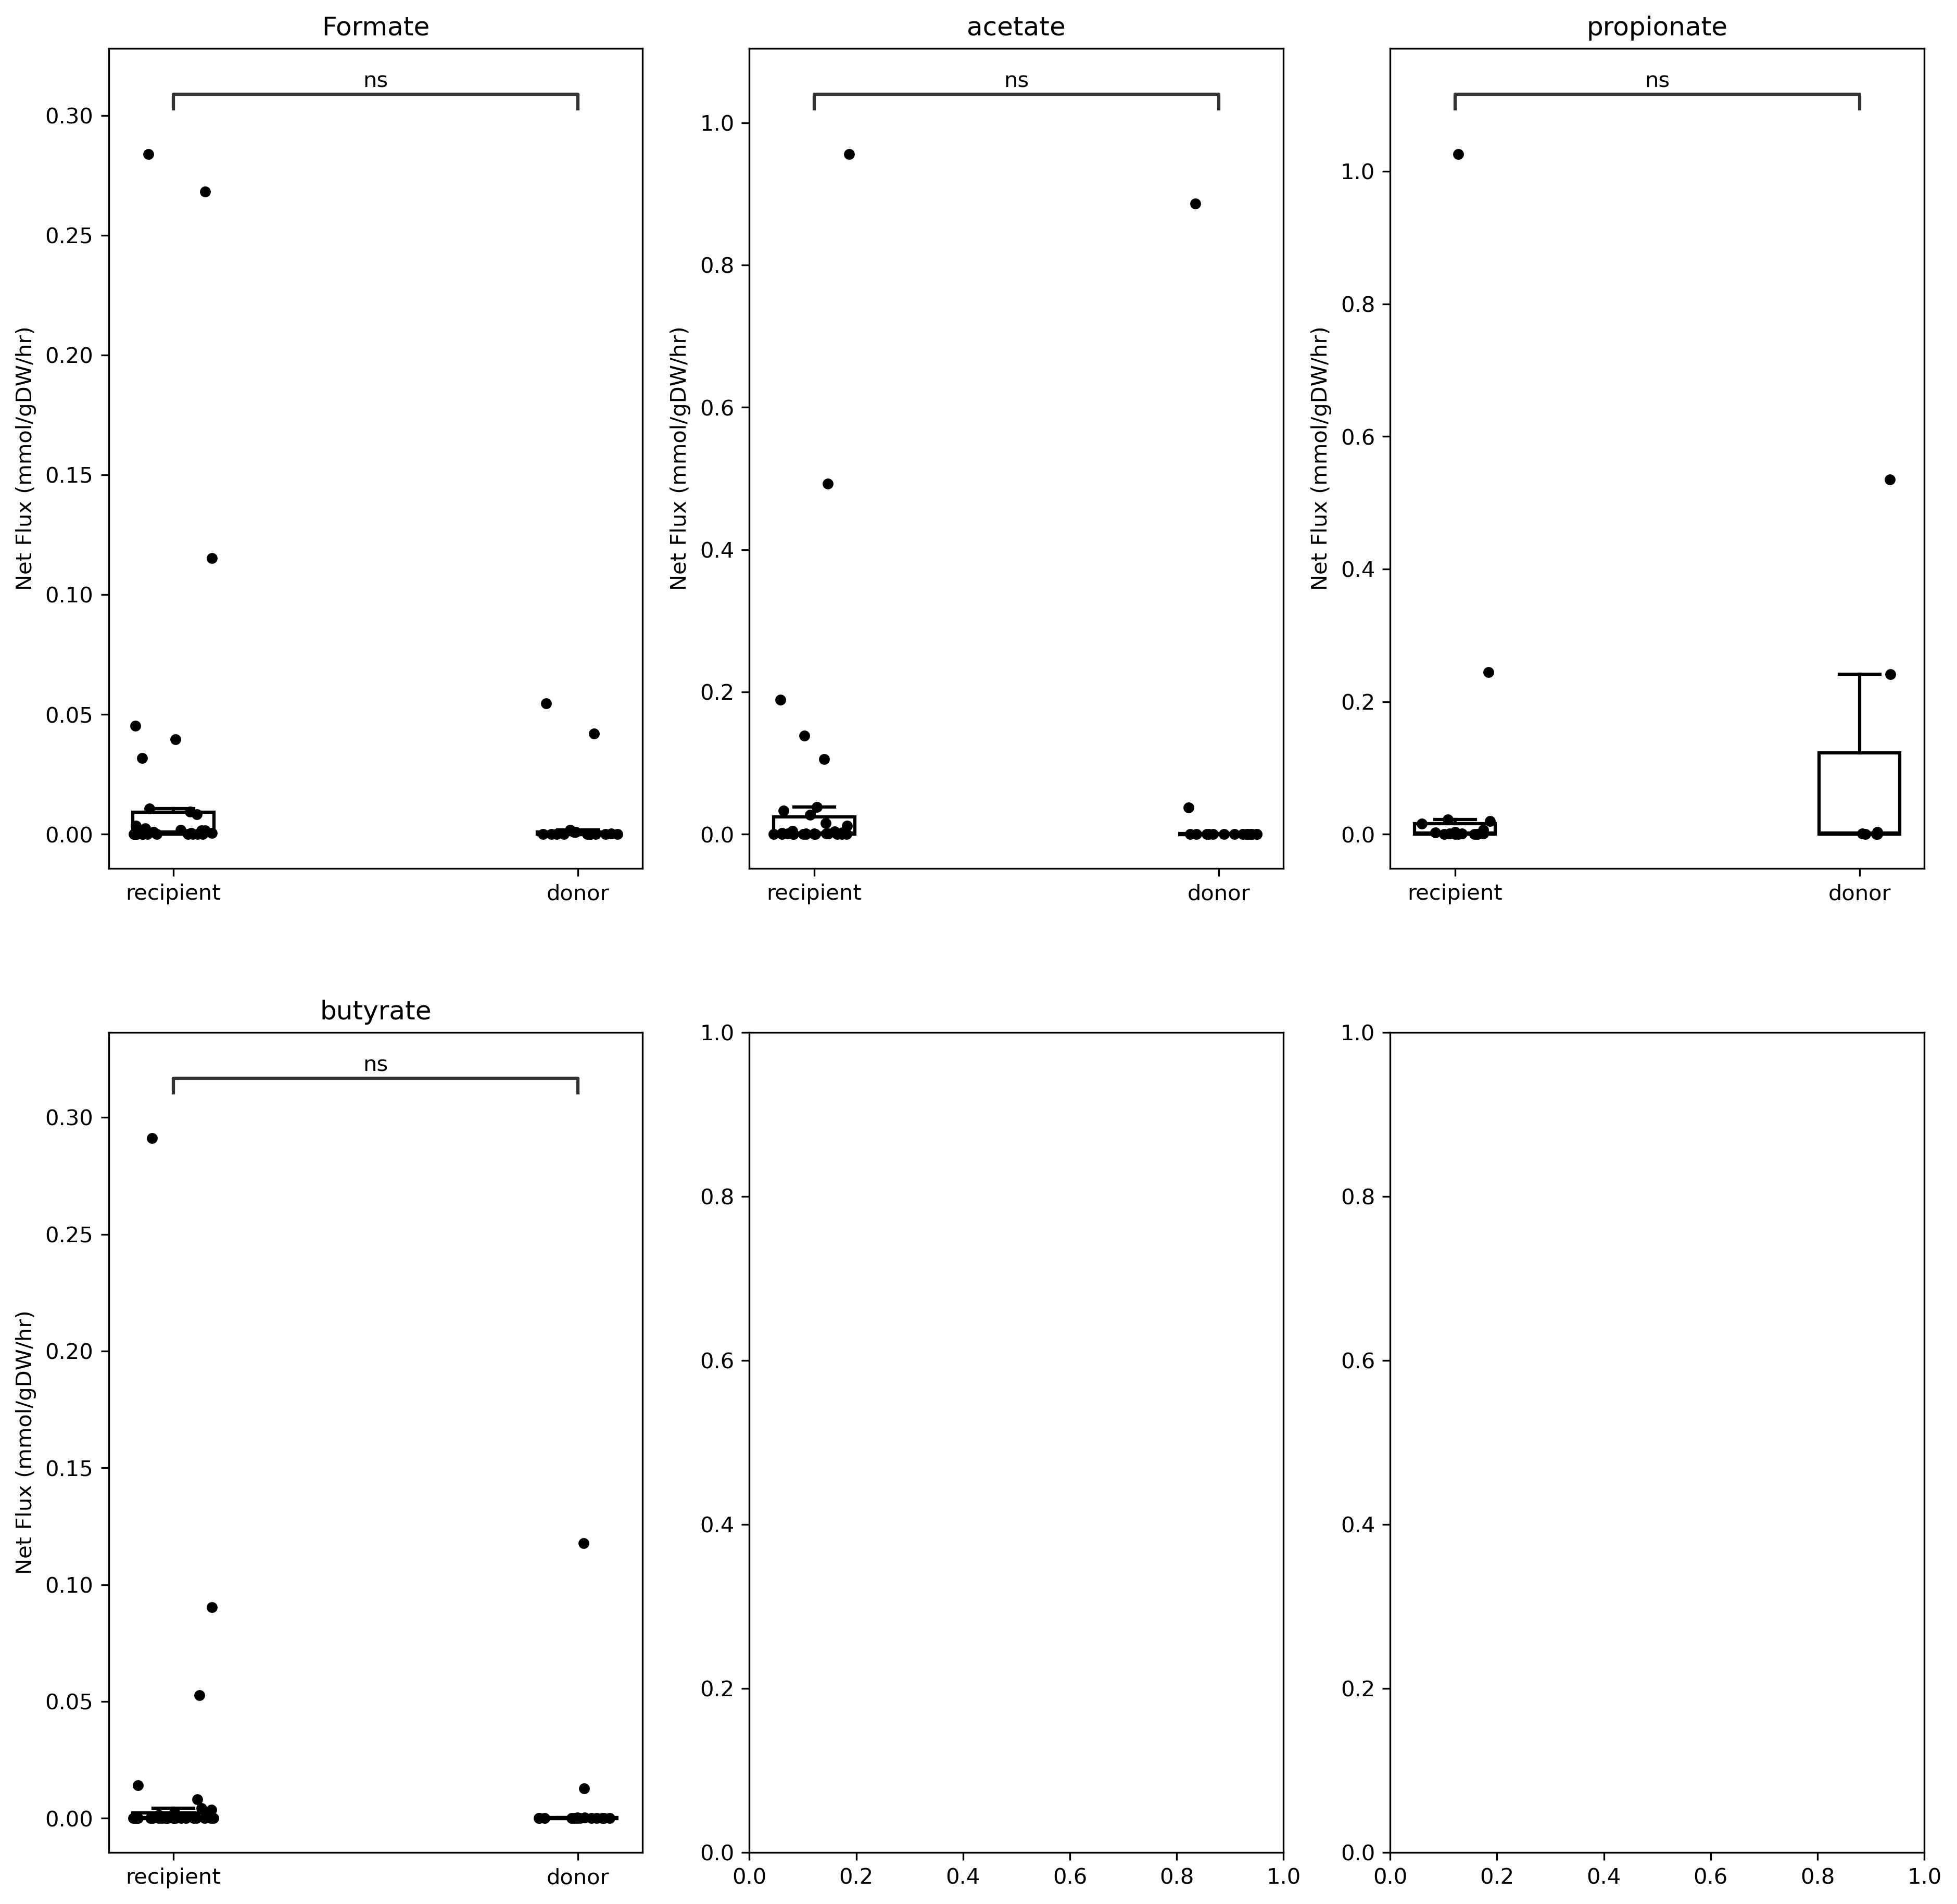

In [67]:
# visualize with boxplot and add stat annotation
f, axes = plt.subplots(2, 3, figsize=(15, 15), dpi=300)
axes = axes.flatten()
for i, (metabolite_name, metabolite_id) in enumerate(metabolites_to_plot.items()):
    ax = axes[i]
    plot_data = res_combined[res_combined['metabolite'] == metabolite_id]
    bp = sns.boxplot(
        data=plot_data, 
        x='clinical_response', y='net_flux',
        showfliers=False,
        width=0.2,
        ax=ax,
        **KWARGS
    )
    sns.stripplot(
        data=plot_data,
        x='clinical_response', y='net_flux',
        color='black',
        size=5,
        jitter=True,
        ax=ax
    )
    add_stat_annotation(
        ax=ax,
        data=plot_data,
        x='clinical_response',
        y='net_flux',
        box_pairs=[('donor', 'recipient')],
        test='t-test_ind',
        text_format='star',
        loc='inside',
        verbose=2
    )
    ax.set_title(metabolite_name)
    ax.set_xlabel('')
    ax.set_ylabel('Net Flux (mmol/gDW/hr)')

<Axes: xlabel='clinical_response', ylabel='Bacteroidetes'>

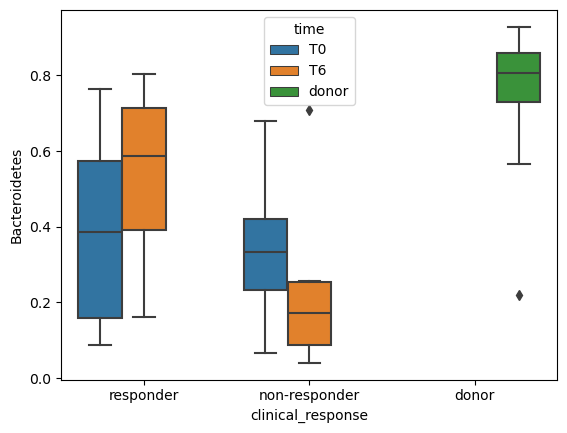

In [68]:
fig = pd.read_csv('../../Figure2/data/supp_4.csv')
sns.boxplot(
    data=fig,
    x='clinical_response',
    y='Bacteroidetes',
    hue='time'
)

In [107]:
# first, filter res by metabolites_to_plot, then merge it with a dataframe that contains taxonomy at phylum level, and then sum the fluxes by phylum and sample_id
res_fluxes = res.exchanges.query('metabolite in @metabolites_to_plot.values() and direction == "export"')
res_fluxes = res_fluxes[~res_fluxes['sample_id'].str.endswith('-6')]
res_fluxes['flux'] = res_fluxes['abundance'] * res_fluxes['flux']
res_fluxes['clinical_response'] = res_fluxes['sample_id'].apply(lambda x: 'recipient' if x.endswith('-0') else 'donor')
ref_tax = pd.read_csv('../processed/full_taxonomy.csv')
ref_tax = ref_tax[['taxon_id', 'phylum']].set_index('taxon_id')
ref_tax.index = pd.to_numeric(ref_tax.index, errors='coerce').astype(int)
res_fluxes = res_fluxes.merge(ref_tax, left_on='taxon', right_index=True, how='left')
res_fluxes_grouped = res_fluxes.groupby(['sample_id', 'clinical_response', 'phylum', 'metabolite']).agg({'flux': 'sum', 'abundance': 'sum'}).reset_index()

In [108]:
res_fluxes_grouped

,sample_id,clinical_response,phylum,metabolite,flux,abundance
0,11-0,recipient,Actinobacteria,ac[e],2.774611,0.031237
1,11-0,recipient,Actinobacteria,for[e],11.826292,0.043301
2,11-0,recipient,Actinobacteria,ppa[e],0.001504,0.028321
3,11-0,recipient,Bacteroidetes,ac[e],1.841479,0.079896
4,11-0,recipient,Bacteroidetes,for[e],1.726761,0.095266
...,...,...,...,...,...,...
648,D-9Fryst,donor,Firmicutes,but[e],0.648572,0.034322
649,D-9Fryst,donor,Firmicutes,for[e],0.401199,0.027039
650,D-9Fryst,donor,Firmicutes,ppa[e],0.023982,0.030624
651,D-9Fryst,donor,Proteobacteria,ac[e],0.989256,0.004751


In [123]:
def plot_metabolite_production_vs_abundance(
    df,
    metabolite_name,
    metabolites_to_plot,
    flux_col="flux",
    abundance_col="abundance",
    sample_col="sample_id",
    group_col="clinical_response",
    phylum_col="phylum",
    figsize=(12, 5),
    dpi=300
):
    """
    Plot side-by-side phylum contribution to metabolite production vs abundance.

    Parameters
    ----------
    df : pd.DataFrame
        Must contain columns:
        [sample_id, clinical_response, phylum, metabolite, flux, abundance]

    metabolite_name : str
        Human-readable metabolite name (key in metabolites_to_plot)

    metabolites_to_plot : dict
        Mapping from metabolite_name -> MICOM metabolite ID
        e.g. {"butyrate": "ppa[e]"}

    flux_col, abundance_col, sample_col, group_col, phylum_col : str
        Column names (override if needed)

    figsize : tuple
        Figure size

    dpi : int
        Figure DPI
    """

    # -------------------------
    # 0) Resolve MICOM metabolite ID
    # -------------------------
    if metabolite_name not in metabolites_to_plot:
        raise ValueError(
            f"Metabolite '{metabolite_name}' not found in metabolites_to_plot."
        )

    micom_met = metabolites_to_plot[metabolite_name]

    # -------------------------
    # 1) Production (positive flux only)
    # -------------------------
    df_prod = df[
        (df["metabolite"] == micom_met) &
        (df[flux_col] > 0)
    ].copy()

    if df_prod.empty:
        raise ValueError(
            f"No positive flux found for metabolite '{micom_met}'."
        )

    df_prod["fraction"] = (
        df_prod
        .groupby(sample_col)[flux_col]
        .transform(lambda x: x / x.sum())
    )

    # -------------------------
    # 2) Abundance (same samples)
    # -------------------------
    df_ab = df[
        df["metabolite"] == micom_met
    ].copy()

    df_ab["fraction"] = (
        df_ab
        .groupby(sample_col)[abundance_col]
        .transform(lambda x: x / x.sum())
    )

    # -------------------------
    # 3) Plot
    # -------------------------
    fig, axes = plt.subplots(
        1, 2, figsize=figsize, dpi=dpi, sharey=True
    )

    sns.barplot(
        data=df_prod,
        x=group_col,
        y="fraction",
        hue=phylum_col,
        estimator="mean",
        errorbar="se",
        ax=axes[0]
    )

    axes[0].set_title(f"{metabolite_name} production")
    axes[0].set_ylabel("Fraction")
    axes[0].set_xlabel("")
    axes[0].set_ylim(0, 1.05)
    axes[0].legend_.remove()

    sns.barplot(
        data=df_ab,
        x=group_col,
        y="fraction",
        hue=phylum_col,
        estimator="mean",
        errorbar="se",
        ax=axes[1]
    )

    axes[1].set_title(f"{metabolite_name} producing phylum abundance")
    axes[1].set_ylabel("")
    axes[1].set_xlabel("")

    axes[1].legend(
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
        title="Phylum"
    )

    plt.tight_layout()
    plt.show()

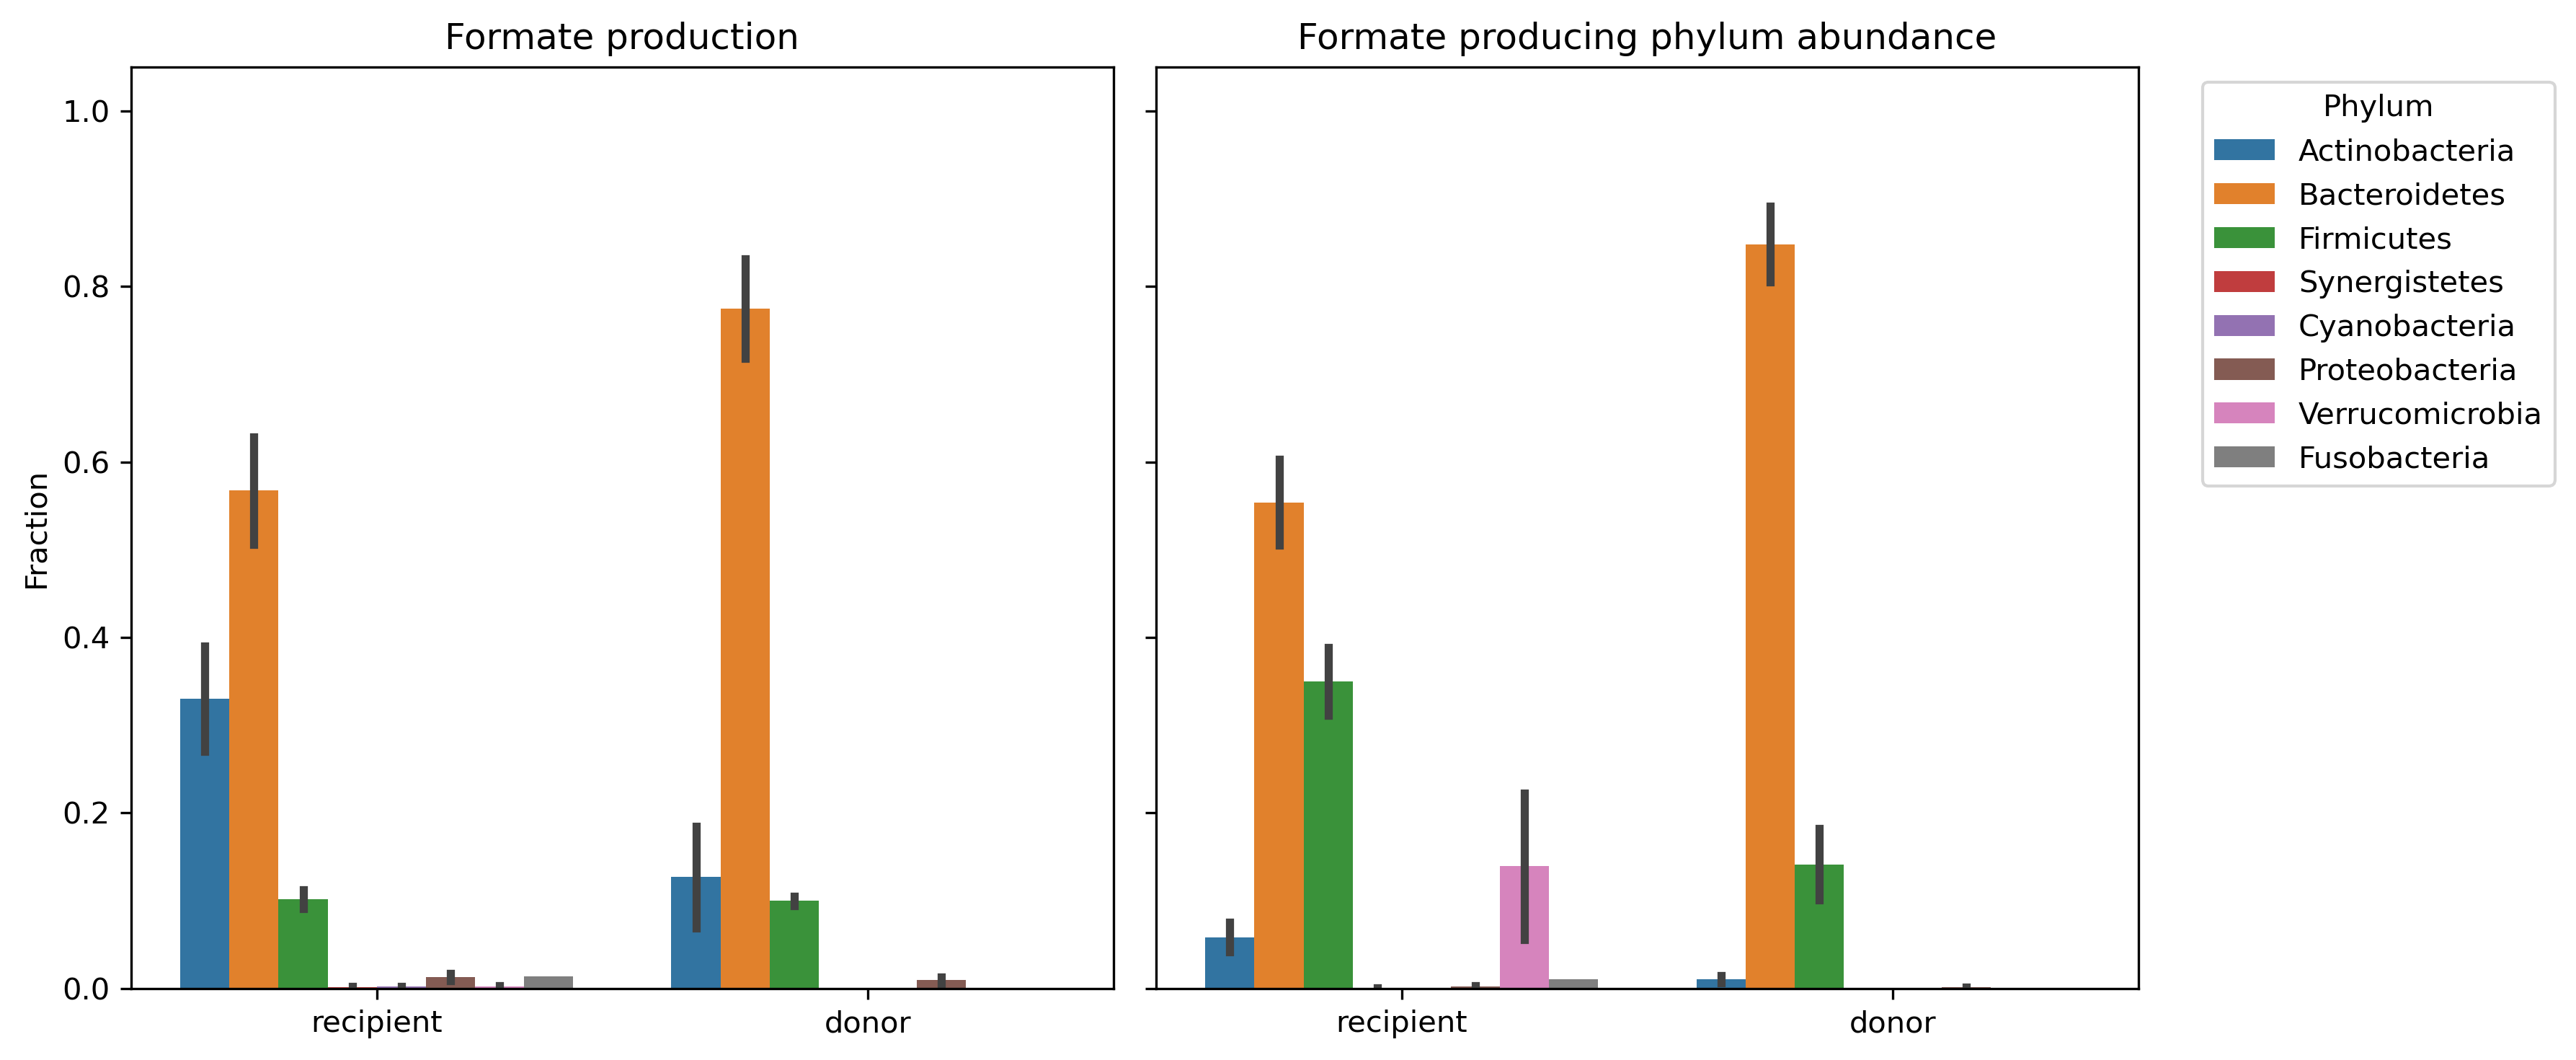

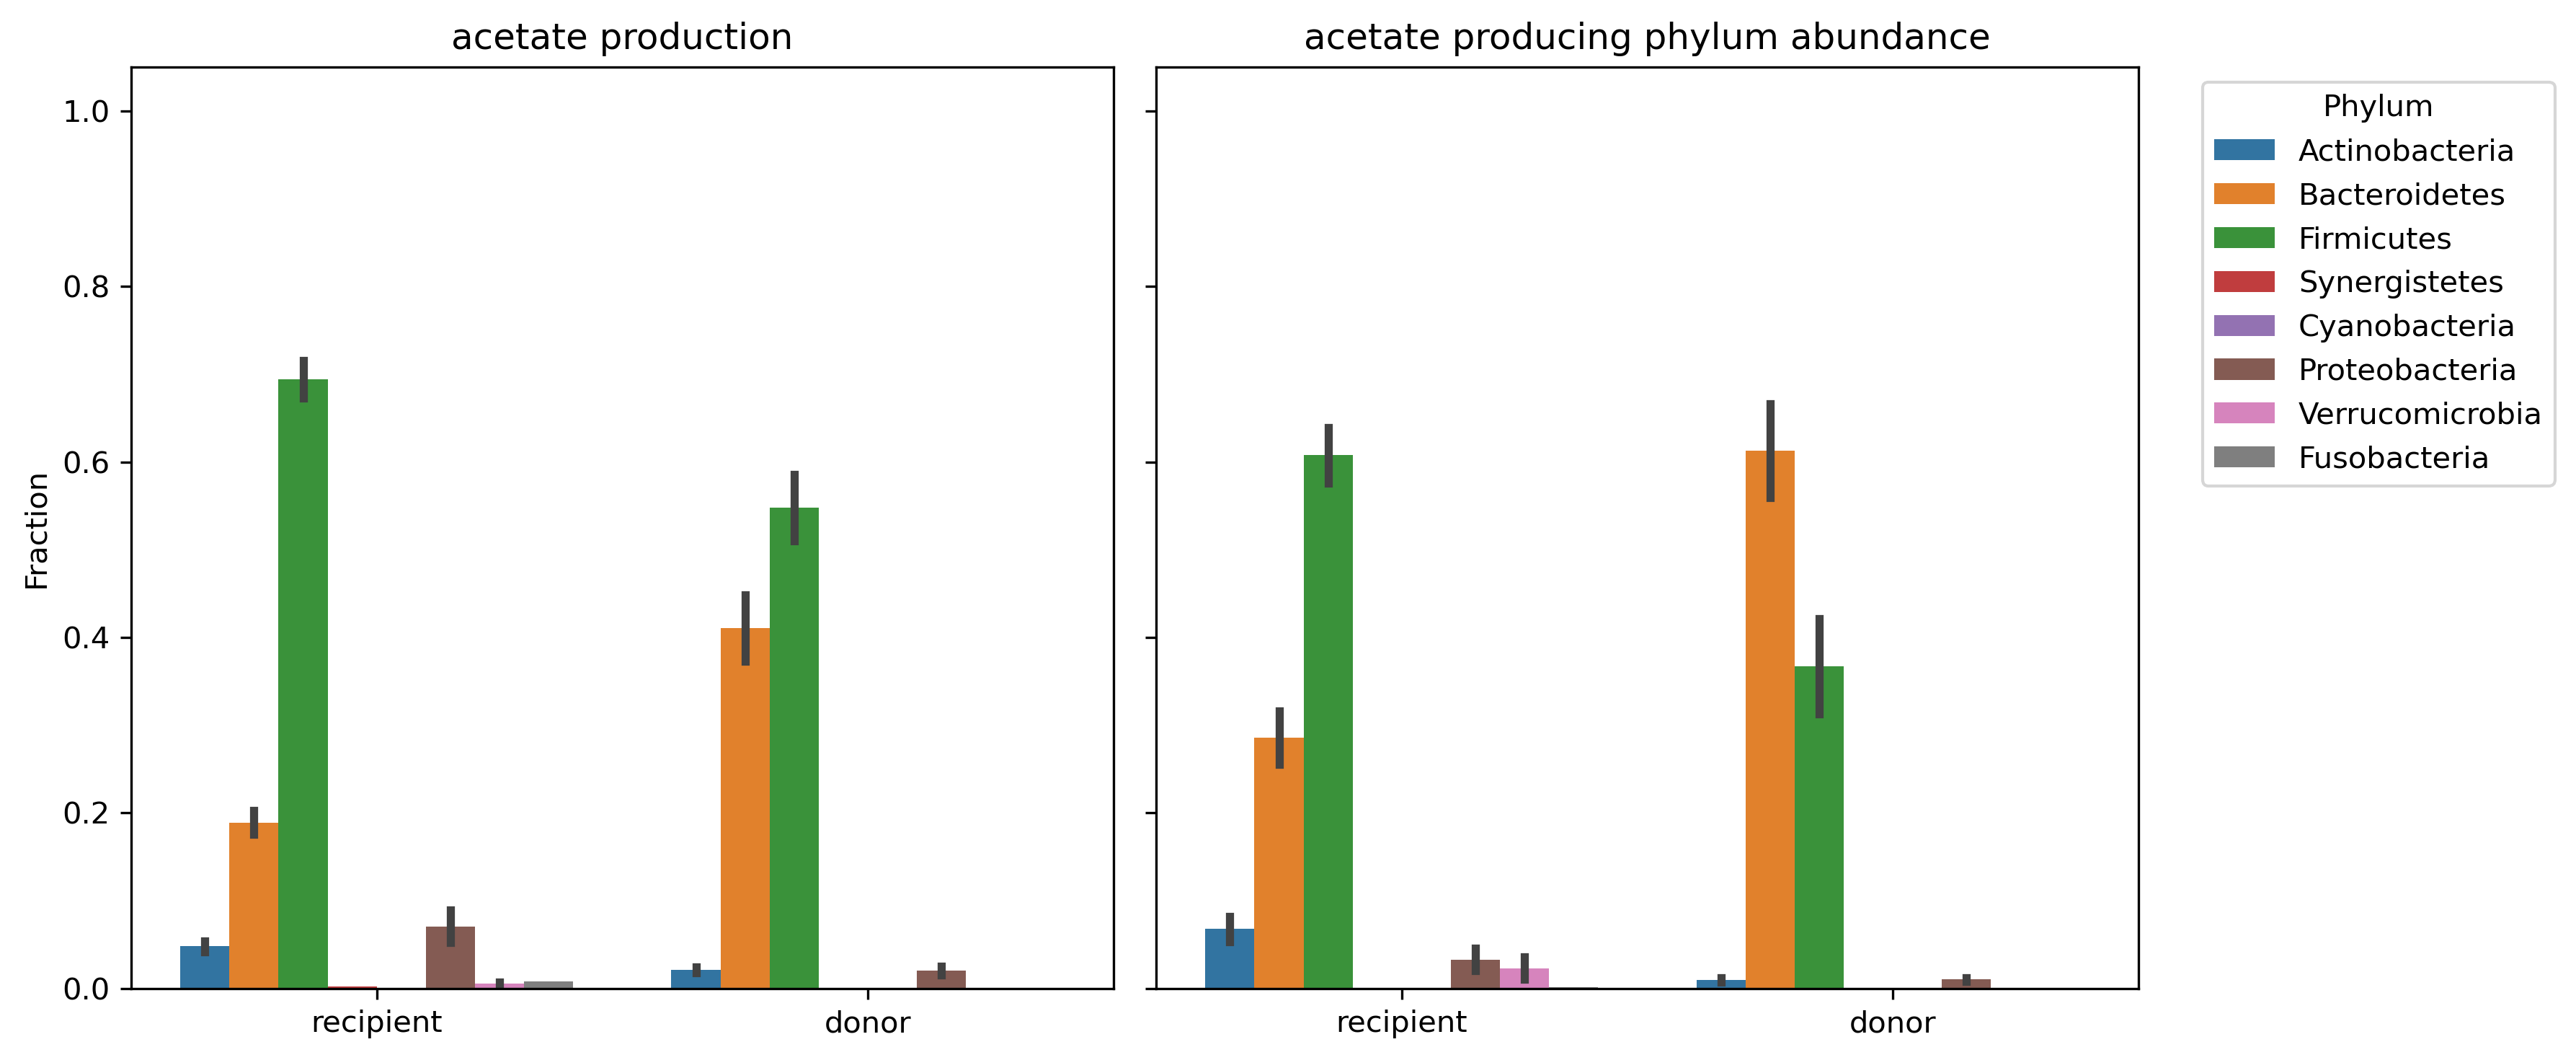

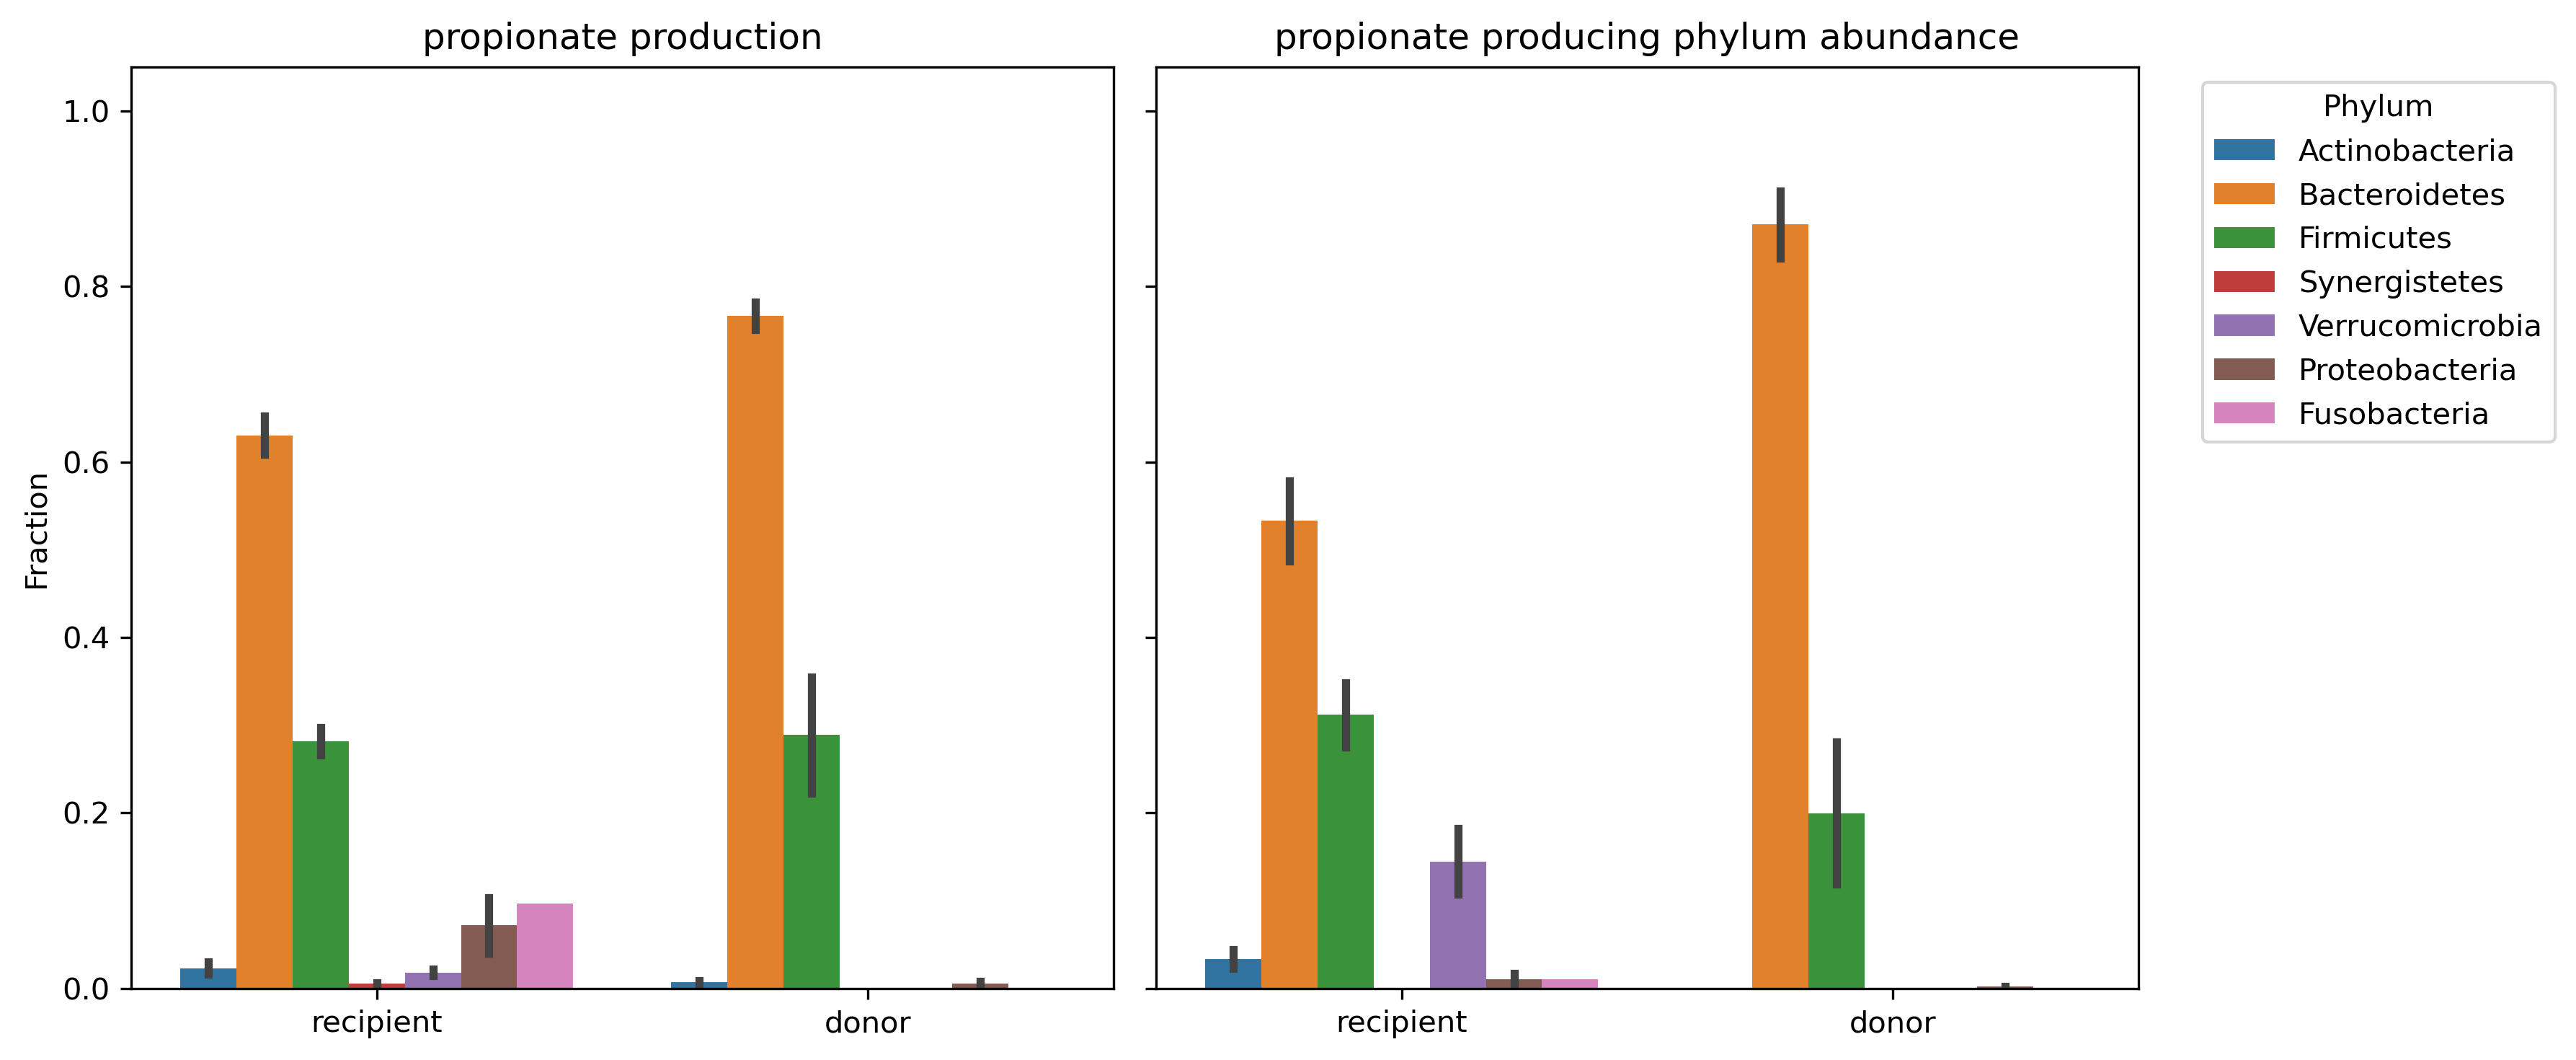

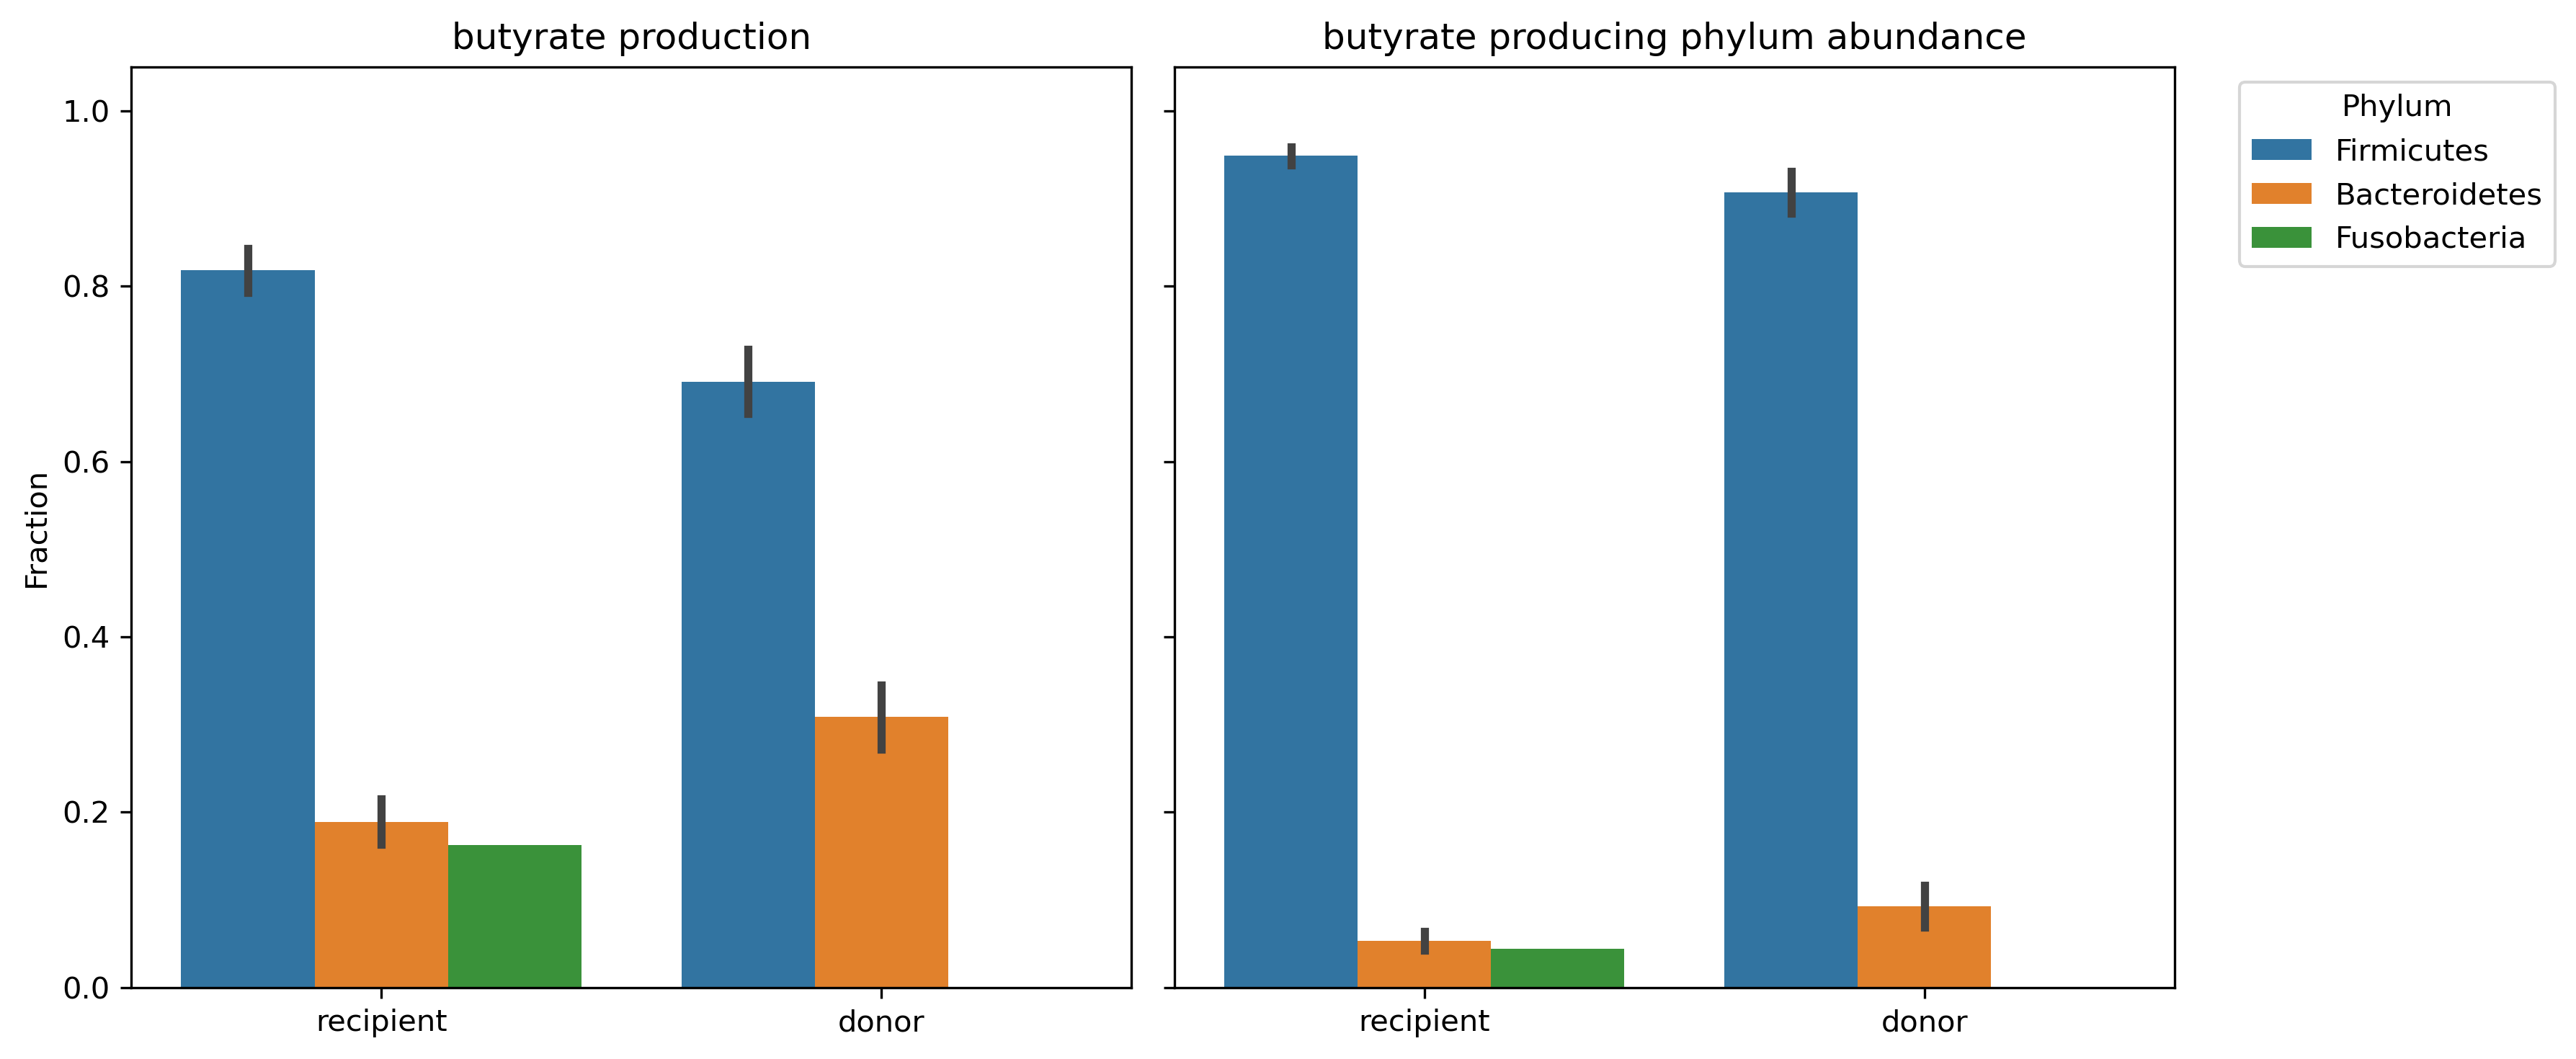

In [125]:
for metabolite_name in metabolites_to_plot.keys():
    plot_metabolite_production_vs_abundance(
        df=res_fluxes_grouped,
        metabolite_name=metabolite_name,
        metabolites_to_plot=metabolites_to_plot
    )

In [130]:
res_growth = res.growth_rates.copy()
res_growth = res_growth[~res_growth.sample_id.str.endswith('-6')]
res_growth['clinical_response'] = res_growth.sample_id.apply(lambda x: 'recipient' if x.endswith('-0') else 'donor')
res_growth = res_growth[['sample_id', 'taxon', 'abundance', 'clinical_response']]
res_growth = res_growth.merge(ref_tax, left_on='taxon', right_index=True, how='left')
res_growth_grouped = res_growth.groupby(['sample_id', 'clinical_response', 'phylum']).agg({'abundance': 'sum'}).reset_index()
res_growth_grouped

,sample_id,clinical_response,phylum,abundance
0,11-0,recipient,Actinobacteria,0.087822
1,11-0,recipient,Bacteroidetes,0.098608
2,11-0,recipient,Firmicutes,0.564837
3,11-0,recipient,Synergistetes,0.000144
4,11-0,recipient,Verrucomicrobia,0.248588
...,...,...,...,...
224,D-9Feresk,donor,Proteobacteria,0.008679
225,D-9Fryst,donor,Actinobacteria,0.001210
226,D-9Fryst,donor,Bacteroidetes,0.931926
227,D-9Fryst,donor,Firmicutes,0.062114


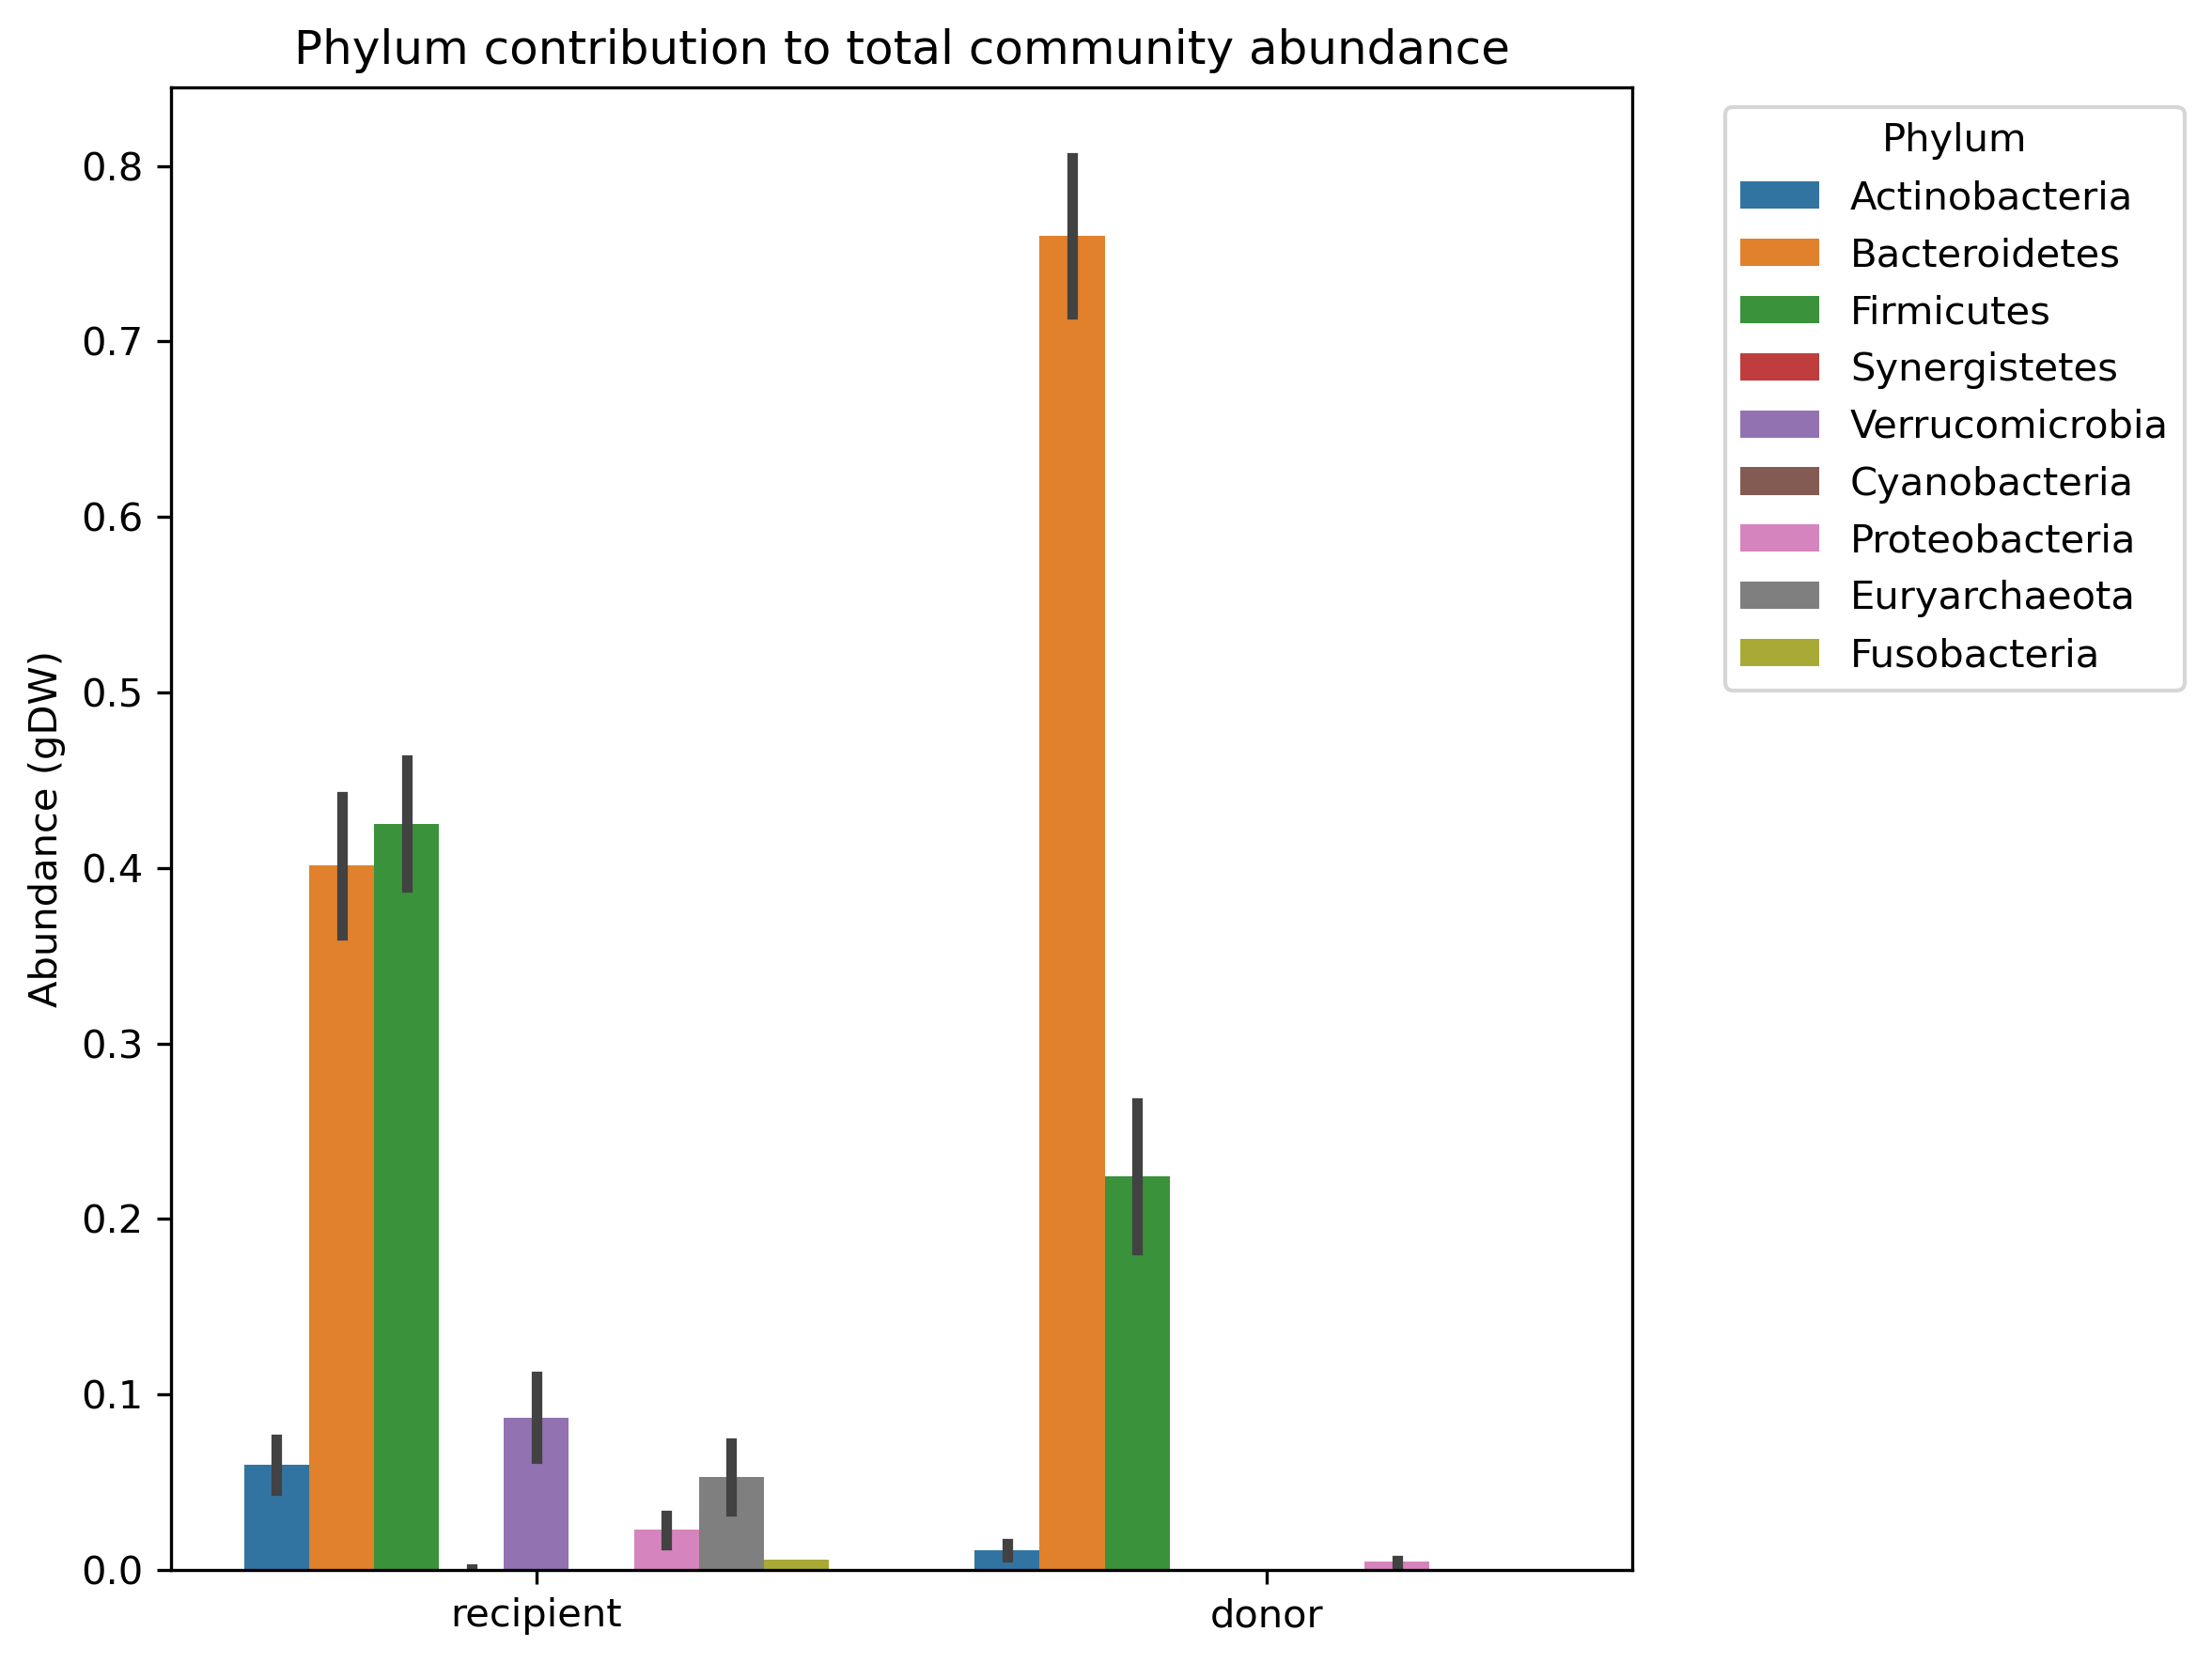

In [131]:
# plot abundance contribution by phylum
plt.figure(figsize=(8, 6), dpi=300)
sns.barplot(
    data=res_growth_grouped,
    x='clinical_response',
    y='abundance',
    hue='phylum',
    estimator='mean',
    errorbar='se'
)
plt.ylabel('Abundance (gDW)')
plt.xlabel('')
plt.title('Phylum contribution to total community abundance')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Phylum')
plt.tight_layout()
plt.show()
